## Stock Analysis using ML
#### Author: Sachin Kumar B
#### Date: 01/01/2024

In [1]:
# %pip install piplite

In [2]:
# import piplite
# await piplite.install(['pandas'])
# await piplite.install(['numpy'])
# await piplite.install(['seaborn'])
# await piplite.install(['pandas_ta'])
# await piplite.install(['yfinance'])
# await piplite.install(['pandas_datareader'])
# await piplite.install(['sklearn'])
# await piplite.install(['matplotlib'])
# await piplite.install(['plotly'])
# await piplite.install(['nltk'])
# await piplite.install(['textblob'])
# await piplite.install(['vaderSentiment'])
# await piplite.install(['transformers'])
# await piplite.install(['scipy'])
# await piplite.install(['statsmodels'])
# await piplite.install(['fredapi'])

In [1]:
# import re
import os
# import pytz
# import nltk
# import wbdata
# import urllib3
import time
import textblob 
import requests
import numpy as np
import pandas as pd
import seaborn as sns
# import vaderSentiment
import yfinance as yf
# import pandas_ta as ta
from fredapi import Fred
import statsmodels.api as sm
# from pandas_ta import Imports
from textblob import TextBlob
from bs4 import BeautifulSoup
from selenium import webdriver
import matplotlib.pyplot as plt
from selenium.webdriver.common.by import By
# from nltk.corpus import stopwords
# from transformers import pipeline
# import pandas_datareader as pdr
# import pandas_datareader.data as web
from sklearn.metrics import precision_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from datetime import date, datetime, timedelta
from pandas.plotting import autocorrelation_plot
from dateutil.relativedelta import relativedelta
# from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
# from statsmodels.tsa.stattools import grangercausalitytests
# from sklearn.metrics import mean_squared_error, mean_absolute_error
# from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [2]:
# Base datetime (current time)
now = datetime.now()

# Date formats
date_format = "%Y-%m-%d"
datetime_format = "%Y-%m-%d %H:%M:%S+0530"

# Dates
prevDate = (now - timedelta(days=1)).strftime(date_format)
currDate = now.strftime(date_format)
endDate = (now + timedelta(days=3)).strftime(date_format)

tenYrDate = (now - relativedelta(years=10)).strftime(date_format)
_52WeeksDate = (now - relativedelta(weeks=52)).strftime(date_format)

# DateTimes
updateDT = now.strftime(datetime_format)
prevDT = (now - timedelta(days=1)).strftime(datetime_format)
endDT = (now + timedelta(days=3)).strftime(datetime_format)

print(prevDate, currDate, endDate, tenYrDate, _52WeeksDate, updateDT, prevDT, endDT)

2026-02-12 2026-02-13 2026-02-16 2016-02-13 2025-02-14 2026-02-13 13:37:55+0530 2026-02-12 13:37:55+0530 2026-02-16 13:37:55+0530


### Load Excel Sheet

In [3]:
excelPath = "Indian_Stocks_NSE.xlsx"

stocksList = pd.read_excel(excelPath, sheet_name="Stocks_Lists_NSE")
holidaysList = pd.read_excel(excelPath, sheet_name="Trading_Holidays")
stocksList.head()

,Symbol,Company Name,Exchange,Symbol_Exchange,Series,Sectors,Industry,Date of Listing,Paid Up Value,Market Lot,ISIN Number,Face Value
0,20MICRONS,20 Microns Limited,NSE,20MICRONS.NS,EQ,Basic Materials,Other Industrial Metals & Mining,2008-10-06,5,1,INE144J01027,5
1,21STCENMGM,21st Century Management Services Limited,NSE,21STCENMGM.NS,EQ,Financial Services,Management Services,1995-05-03,10,1,INE253B01015,10
2,360ONE,360 ONE WAM LIMITED,NSE,360ONE.NS,EQ,Financial Services,Investment Management,2019-09-19,1,1,INE466L01038,1
3,3IINFOLTD,3i Infotech Limited,NSE,3IINFOLTD.NS,EQ,Technology,IT Services,2021-10-22,10,1,INE748C01038,10
4,3MINDIA,3M India Limited,NSE,3MINDIA.NS,EQ,Consumer Goods,Diversified Industrial Products,2004-08-13,10,1,INE470A01017,10


In [4]:
# # Google Sheet URL
# url = "https://docs.google.com/spreadsheets/d/1ZSFuFlaILJoiQNDDuGosOY-jIMTjNcX8_UHJVH5b4Jo/edit#gid=0"

# # Extract the Sheet ID
# GSHEET_ID = re.search(r"/d/([a-zA-Z0-9-_]+)", url).group(1)

# # Fetch metadata to get all sheet names dynamically
# meta_url = f"https://docs.google.com/spreadsheets/d/{GSHEET_ID}/gviz/tq?"
# meta_data = requests.get(meta_url).text

# # Extract all sheet names using regex
# sheet_names = re.findall(r"\"(.*?)\"", meta_data)
# gsheets = [name for name in sheet_names if name and "gid" not in name]  # filter non-names
# print("Sheets found:", gsheets)

# # Load all sheets into DataFrames
# gs_dataframes = {}

# for name in gsheets:
#     csv_url = f"https://docs.google.com/spreadsheets/d/{GSHEET_ID}/gviz/tq?tqx=out:csv&sheet={name}"
#     df = pd.read_csv(csv_url)
#     gs_dataframes[name] = df
#     print(f"\nData from {name}:\n", df.head())

# # Combine all sheets if needed (if they have same columns)
# combined_df = pd.concat(gs_dataframes.values(), ignore_index=True)
# print("\nCombined Data:\n", combined_df.head())

In [5]:
weekHolidays = ['Sunday', 'Saturday']
tradeWeekHolidays = pd.concat([holidaysList['Week'], pd.Series(weekHolidays)], ignore_index=True)

In [6]:
# wdf = pd.read_csv('Trading_Holidays.csv')
# tradingHolidays = wdf['Week']

# tradeWeekHolidays = pd.concat([tradingHolidays, pd.Series(weekHolidays)], ignore_index=True)
# tradeWeekHolidays

In [7]:
selectedCompanyName = "Reliance Power Limited"
tickersListName = (stocksList.loc[stocksList["Company Name"] == selectedCompanyName, "Symbol_Exchange"].iloc[0])

stockTicker = yf.Ticker(tickersListName)
tickHistory = stockTicker.history(period="max")

In [8]:
# tickersListName = "RPOWER.NS"
# stockTicker = yf.Ticker(tickersListName)
# tickHistory = stockTicker.history(period="max")

In [9]:
sector = (stocksList.loc[stocksList["Company Name"] == selectedCompanyName, "Sectors"].iloc[0])
industry = (stocksList.loc[stocksList["Company Name"] == selectedCompanyName, "Industry"].iloc[0])
tickerSymbol = (stocksList.loc[stocksList["Company Name"] == selectedCompanyName, "Symbol"].iloc[0])
startDate = tickHistory.index.min()
print({"Start Date":startDate, "Symbol": tickerSymbol, "Company Name": selectedCompanyName, "Sector": sector, "Industry": industry})

{'Start Date': Timestamp('2008-02-11 00:00:00+0530', tz='Asia/Kolkata'), 'Symbol': 'RPOWER', 'Company Name': 'Reliance Power Limited', 'Sector': 'Energy', 'Industry': 'Power Generation'}


In [10]:
# # Fetch and print industry and sector information
# sector = stockTicker.info.get('sector')
# industry = stockTicker.info.get('industry')
# tickerSymbol = tickersListName.replace(".NS", "")
# startDate = tickHistory.index.min()

# print({"Start Date":startDate, "Symbol": tickerSymbol, "Company Name": selectedCompanyName, "Sector": sector, "Industry": industry})

### Fundamental Analysis

In [11]:
financials = stockTicker.financials  # Get financial statements
balance_sheet = stockTicker.balance_sheet  # Get balance sheet
cashflow = stockTicker.cashflow  # Get cash flow statements

# Display the financial data
financials
# print(balance_sheet)
# print(cashflow)

,2025-03-31,2024-03-31,2023-03-31,2022-03-31,2021-03-31
Tax Effect Of Unusual Items,1.125821e+09,3.825900e+08,3.052290e+09,2.640000e+06,NaN
Tax Rate For Calcs,3.278000e-02,3.000000e-01,3.000000e-01,3.000000e-01,NaN
Normalized EBITDA,2.407450e+10,1.129250e+10,1.785180e+10,2.833930e+10,NaN
Total Unusual Items,3.437320e+10,1.275300e+09,1.017430e+10,8.800000e+06,NaN
Total Unusual Items Excluding Goodwill,3.434480e+10,1.275300e+09,1.017430e+10,8.800000e+06,NaN
Net Income From Continuing Operation Net Minority Interest,2.947400e+10,-2.242180e+10,-4.107700e+09,-9.726000e+09,NaN
Reconciled Depreciation,1.096020e+10,1.256750e+10,1.227750e+10,1.275050e+10,NaN
Reconciled Cost Of Revenue,4.219430e+10,4.155200e+10,3.956530e+10,3.305330e+10,NaN
EBITDA,5.844770e+10,1.256780e+10,2.802610e+10,2.834810e+10,NaN
EBIT,4.748750e+10,3.000000e+05,1.574860e+10,1.559760e+10,NaN


In [12]:
# print(round(tickHistory,2))
tickHistory

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2008-02-11 00:00:00+05:30,324.510421,324.510421,217.544439,229.606430,215028070,0.0,0.0
2008-02-12 00:00:00+05:30,233.494437,241.852111,207.258075,217.024002,66575923,0.0,0.0
2008-02-13 00:00:00+05:30,223.483605,225.718441,203.890522,214.391190,39014579,0.0,0.0
2008-02-14 00:00:00+05:30,217.942431,229.606438,217.942431,226.514404,20221843,0.0,0.0
2008-02-15 00:00:00+05:30,219.871132,238.147805,217.973052,235.423141,28134886,0.0,0.0
...,...,...,...,...,...,...,...
2026-02-06 00:00:00+05:30,27.850000,28.090000,27.299999,27.980000,36274661,0.0,0.0
2026-02-09 00:00:00+05:30,28.500000,28.850000,27.860001,28.430000,37947374,0.0,0.0
2026-02-10 00:00:00+05:30,28.500000,29.450001,28.250000,28.459999,33121117,0.0,0.0


In [13]:
# Get stock price
price = stockTicker.history(period="1d")['Close'].iloc[0]

# Market Capitalization
marketCapital = stockTicker.info["marketCap"]

# Net Income
netIncome = financials.loc["Net Income"].iloc[0]

# Dividends
dividends = stockTicker.dividends

# Outstanding Shares
outstandingShares = stockTicker.info.get("sharesOutstanding")

# Get Earnings Per Share (EPS)
# eps = stockTicker.info['trailingEps']
eps = round(((netIncome - dividends)/outstandingShares),6)

# Market Price Per Share
marketPricePerShare = round(marketCapital / outstandingShares,6)

# Calculate P/E
pe = round((marketPricePerShare / eps),6)
print(f"P/E: {pe}")

# Calculate P/E Ratio
pe_ratio = price / eps
print(f"P/E Ratio: {pe_ratio}")

# Close Value using pe and eps
closeVal = round((pe * eps),2)
print(f"Close Value: {closeVal}")

# Get book value per share
book_value_per_share = stockTicker.info['bookValue']

# Calculate P/B Ratio
pb_ratio = price / book_value_per_share
print(f"P/B Ratio: {pb_ratio}")

# Balance Sheet Labels
liabilities_label = balance_sheet.index[balance_sheet.index.str.contains("Total Liabilities", case=False, na=False)]
equity_label = balance_sheet.index[balance_sheet.index.str.contains("Stockholders Equity", case=False, na=False)]

# Get total liabilities and shareholders' equity
total_liabilities = balance_sheet.loc[liabilities_label[0]].dropna().iloc[0]  # balance_sheet.loc['Total Liabilities'][0]
shareholder_equity = balance_sheet.loc[equity_label[0]].dropna().iloc[0]  # balance_sheet.loc['Total Stockholder Equity'][0]

# Calculate Debt-to-Equity Ratio
de_ratio = total_liabilities / shareholder_equity
print(f"Debt-to-Equity Ratio: {de_ratio}")

P/E: Date
2015-11-19 00:00:00+05:30    3.79368
Name: Dividends, dtype: float64
P/E Ratio: Date
2015-11-19 00:00:00+05:30    3.792278
Name: Dividends, dtype: float64
Close Value: Date
2015-11-19 00:00:00+05:30    27.04
Name: Dividends, dtype: float64
P/B Ratio: 0.6772908538586662
Debt-to-Equity Ratio: 1.5269305963452688


#### Plot Revenue Over Time

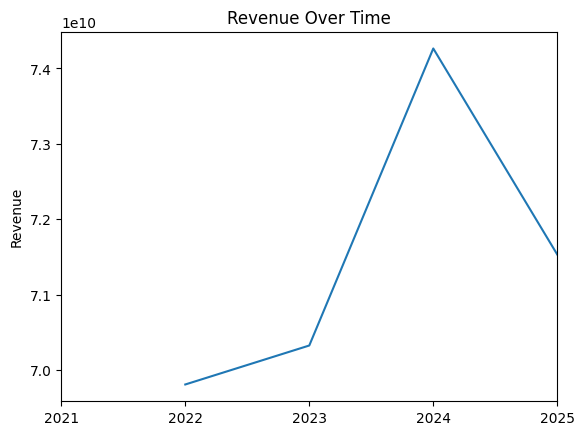

In [14]:
# Plot revenue over time
revenue = financials.loc['Total Revenue']
revenue.plot(kind='line')
plt.title("Revenue Over Time")
plt.ylabel("Revenue")
plt.show()

#### Competitor Companies

In [15]:
competitorStocksDict = {}

competitors = stocksList[(stocksList["Sectors"] == sector) & (stocksList["Industry"] == industry)]

for i in range(len(competitors)):
    if competitors.iloc[i]["Company Name"] != selectedCompanyName:
        competitorStocksDict[competitors.iloc[i]["Symbol_Exchange"]] = competitors.iloc[i]["Company Name"]

competitorStocksDict

{'ADANIPOWER.NS': 'Adani Power Limited',
 'GVKPIL.NS': 'GVK Power & Infrastructure Limited',
 'JPPOWER.NS': 'Jaiprakash Power Ventures Limited',
 'RTNPOWER.NS': 'RattanIndia Power Limited'}

In [16]:
# # Competitor Companies
# cdf = pd.read_csv("Stocks_Lists_NSE.csv")
# competitorStocksDict = {}
# competitors = cdf[(cdf["Sectors"] == sector) & (cdf["Industry"] == industry)]

# for i in range(len(competitors)):
#     if competitors.iloc[i]["Company_Names"] != selectedCompanyName:
#         competitorStocksDict[competitors.iloc[i]["Symbols"]] = [competitors.iloc[i]["Company_Names"], competitors.iloc[i]["Short_Names"]]
# print(competitorStocksDict)

#### Download Data for Competitor Companies

In [17]:
compete_pe_ratio = 0
compete_data = {}
print({"Selected Company Name":selectedCompanyName, "P/E Ratio":pe_ratio})
for sym_exchg, cNames in competitorStocksDict.items():
    competeStockTicker = yf.Ticker(sym_exchg)    
    
    compete_pe_ratio = competeStockTicker.info.get('trailingPE')    
    compete_price = competeStockTicker.history(period="1d")['Close'].iloc[0]
    compete_eps = competeStockTicker.info.get('trailingEps')
    
    compete_pe_ratio_calc = compete_price / compete_eps if compete_eps > 0 else 'N/A'

    compete_data[sym_exchg] = {"Company Name":cNames, "P/E Ratio":compete_pe_ratio, "Calculated P/E Ratio": compete_pe_ratio_calc}

    # compete_data = {'Stock': [tickerSymbol, sym_exchg], 'P/E Ratio': [compete_pe_ratio_calc, compete_pe_ratio]}
    print({"Competitor Symbol_Exchange":sym_exchg, "Competitor Company Name":cNames, "P/E Ratio":compete_pe_ratio, "P/E Ratio Calc": compete_pe_ratio_calc})

{'Selected Company Name': 'Reliance Power Limited', 'P/E Ratio': Date
2015-11-19 00:00:00+05:30    3.792278
Name: Dividends, dtype: float64}
{'Competitor Symbol_Exchange': 'ADANIPOWER.NS', 'Competitor Company Name': 'Adani Power Limited', 'P/E Ratio': 24.134811, 'P/E Ratio Calc': np.float64(24.134811036822736)}
{'Competitor Symbol_Exchange': 'GVKPIL.NS', 'Competitor Company Name': 'GVK Power & Infrastructure Limited', 'P/E Ratio': None, 'P/E Ratio Calc': 'N/A'}
{'Competitor Symbol_Exchange': 'JPPOWER.NS', 'Competitor Company Name': 'Jaiprakash Power Ventures Limited', 'P/E Ratio': 22.787878, 'P/E Ratio Calc': np.float64(22.787878730080344)}
{'Competitor Symbol_Exchange': 'RTNPOWER.NS', 'Competitor Company Name': 'RattanIndia Power Limited', 'P/E Ratio': 35.2, 'P/E Ratio Calc': np.float64(35.20000076293945)}


In [18]:
# # Download data for competitor companies
# compet_pe_ratio = 0
# sym_compet = ""
# for symbol, cNames in competitorStocksDict.items():    
#     sym_compet = symbol
#     stock_compet = yf.Ticker(symbol+".NS")
#     compet_pe_ratio = stock_compet.info['trailingPE']
#     print(f"{selectedCompanyName} P/E Ratio: {pe_ratio}")
#     print(f"{cNames[0]} P/E Ratio: {compet_pe_ratio}")

#### Revenue Growth

In [19]:
# Calculate revenue growth (year over year)
revenue_growth = (revenue.iloc[0] - revenue.iloc[1]) / revenue.iloc[1] * 100
print(f"Revenue Growth YoY: {revenue_growth}%")

Revenue Growth YoY: -3.6792814871169943%


In [20]:
# stocks = [kSym for kSym, vals in competitorStocksDict.items()]
# data = {}
# for stock_symbol in stocks:
#     stock_compt = yf.Ticker(stock_symbol+".NS")
#     price_compt = stock_compt.history(period="1d")['Close'].iloc[0]
#     eps_compt = stock_compt.info['trailingEps']
#     pe_ratio_compt = price_compt / eps_compt if eps_compt > 0 else 'N/A'
#     print(f"{stock_symbol} P/E Ratio: {pe_ratio_compt}")
#     data = {'Stock': [tickerSymbol, stock_symbol], 'P/E Ratio': [pe_ratio_compt, compet_pe_ratio]}

In [21]:
compete_data

{'ADANIPOWER.NS': {'Company Name': 'Adani Power Limited',
  'P/E Ratio': 24.134811,
  'Calculated P/E Ratio': np.float64(24.134811036822736)},
 'GVKPIL.NS': {'Company Name': 'GVK Power & Infrastructure Limited',
  'P/E Ratio': None,
  'Calculated P/E Ratio': 'N/A'},
 'JPPOWER.NS': {'Company Name': 'Jaiprakash Power Ventures Limited',
  'P/E Ratio': 22.787878,
  'Calculated P/E Ratio': np.float64(22.787878730080344)},
 'RTNPOWER.NS': {'Company Name': 'RattanIndia Power Limited',
  'P/E Ratio': 35.2,
  'Calculated P/E Ratio': np.float64(35.20000076293945)}}

In [22]:
# Create a dataframe with the analysis results
    # data = {'Stock': stock_symbol, 'P/E Ratio': pe_ratio}

df = pd.DataFrame(compete_data)
df.to_csv('stock_analysis.csv', index=False)
# print(data)

In [23]:
df

,ADANIPOWER.NS,GVKPIL.NS,JPPOWER.NS,RTNPOWER.NS
Company Name,Adani Power Limited,GVK Power & Infrastructure Limited,Jaiprakash Power Ventures Limited,RattanIndia Power Limited
P/E Ratio,24.134811,None,22.787878,35.2
Calculated P/E Ratio,24.134811,N/A,22.787879,35.200001


### Technical Analysis

In [24]:
# Download stock data (e.g., tickersListName)
stock_data = yf.download(tickersListName, start=_52WeeksDate, end=endDate, auto_adjust=True)

# Display the first few rows of the data
# print(stock_data.head())
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RPOWER.NS,RPOWER.NS,RPOWER.NS,RPOWER.NS,RPOWER.NS
Date,,,,,
2025-02-14,37.270000,39.750000,36.669998,39.590000,29114187
2025-02-17,36.939999,37.889999,35.910000,37.189999,23853325
2025-02-18,36.779999,37.439999,36.070000,37.150002,14308712
2025-02-19,37.950001,38.400002,36.049999,36.279999,19024449
2025-02-20,38.160000,38.650002,37.500000,37.900002,13736316


In [25]:
# Calculate 50-day and 200-day Simple Moving Average (SMA)
stock_data['SMA_50'] = stock_data['Close'].rolling(window=50).mean()
stock_data['SMA_200'] = stock_data['Close'].rolling(window=200).mean()

# Calculate Exponential Moving Average (EMA)
stock_data['EMA_50'] = stock_data['Close'].ewm(span=50, adjust=False).mean()

print(stock_data[['SMA_50', 'SMA_200', 'EMA_50']].tail())


Price        SMA_50   SMA_200     EMA_50
Ticker                                  
Date                                    
2026-02-09  33.5274  46.06910  33.253290
2026-02-10  33.2976  45.98955  33.065318
2026-02-11  33.0764  45.92205  32.861188
2026-02-12  32.8506  45.85330  32.655259
2026-02-13  32.6232  45.78345  32.435053


In [26]:
delta = stock_data['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
stock_data['RSI'] = 100 - (100 / (1 + rs))

print(stock_data[['RSI']].tail())

Price             RSI
Ticker               
Date                 
2026-02-09  40.029760
2026-02-10  44.019522
2026-02-11  43.038979
2026-02-12  40.529698
2026-02-13  44.571934


In [27]:
# Calculate MACD
# macd = ta.macd(close='Close', fast=12, slow=26, signal=9)

# Get the 26-day EMA of the closing price
k = stock_data['Close'].ewm(span=12, adjust=False, min_periods=12).mean()
# Get the 12-day EMA of the closing price
d = stock_data['Close'].ewm(span=26, adjust=False, min_periods=26).mean()
# Subtract the 26-day EMA from the 12-Day EMA to get the MACD
macd = k - d

# The pandas_ta MACD function returns a DataFrame with MACD, Signal, and Histogram columns
if macd is not None:
    # Get the 9-Day EMA of the MACD for the Trigger line
    macd_s = macd.ewm(span=9, adjust=False, min_periods=9).mean()
    
    # Calculate the difference between the MACD - Trigger for the Convergence/Divergence value
    macd_h = macd - macd_s

    # Add all of our new values for the MACD to the dataframe
    stock_data['MACD'] = macd
    stock_data['Histogram'] = macd_h
    stock_data['Signal'] = macd_s
    
    print(stock_data[['MACD', 'Signal']].tail())
else:
    print("MACD calculation returned None. Check data or library installation.")


Price           MACD    Signal
Ticker                        
Date                          
2026-02-09 -1.772790 -1.913259
2026-02-10 -1.667589 -1.864125
2026-02-11 -1.614026 -1.814105
2026-02-12 -1.573610 -1.766006
2026-02-13 -1.569482 -1.726701


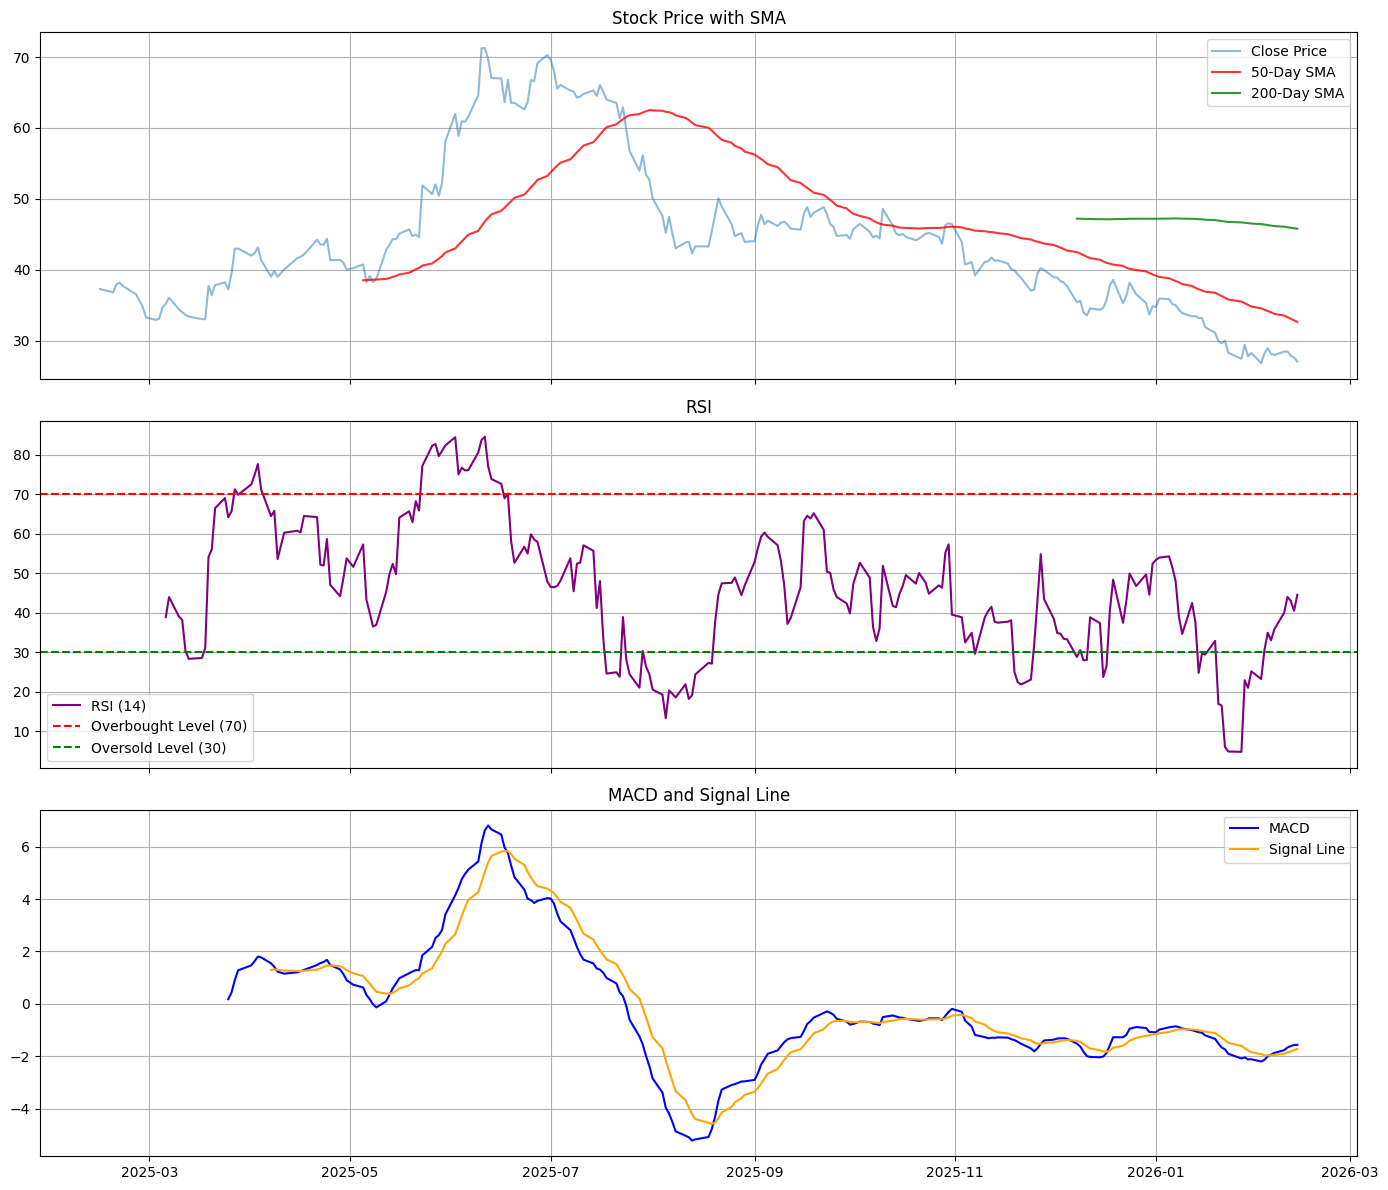

In [28]:
# Plot Closing price, 50-day SMA, and 200-day SMA
# plt.figure(figsize=(12, 6))
# plt.plot(stock_data['Close'], label='Close Price', alpha=0.5)
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# --- Plot 1: Closing Price with SMA ---
axes[0].plot(stock_data['Close'], label='Close Price', alpha=0.5)
axes[0].plot(stock_data['SMA_50'], label='50-Day SMA', color='red', alpha=0.8)
axes[0].plot(stock_data['SMA_200'], label='200-Day SMA', color='green', alpha=0.8)
axes[0].set_title('Stock Price with SMA')
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: RSI ---
axes[1].plot(stock_data['RSI'], label='RSI (14)', color='purple')
axes[1].axhline(70, linestyle='--', color='red', label='Overbought Level (70)')
axes[1].axhline(30, linestyle='--', color='green', label='Oversold Level (30)')
axes[1].set_title('RSI')
axes[1].legend()
axes[1].grid(True)

# --- Plot 3: MACD and Signal Line ---
axes[2].plot(stock_data['MACD'], label='MACD', color='blue')
axes[2].plot(stock_data['Signal'], label='Signal Line', color='orange')
axes[2].set_title('MACD and Signal Line')
axes[2].legend()
axes[2].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_2336\4196595765.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data['Signal'][50:] = np.where(stock_data['SMA_50'][50:] > stock_data['SMA_200'][50:], 1, 0)  # Buy signal


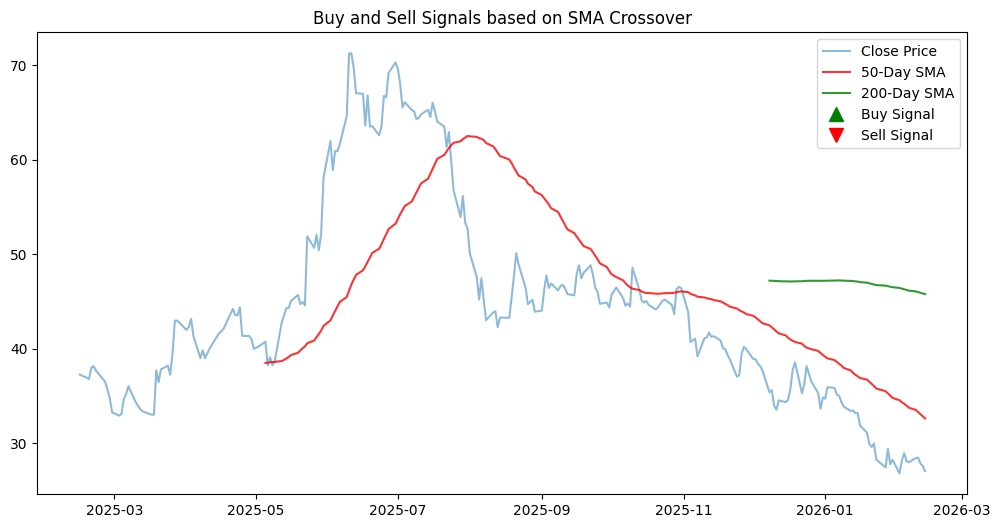

In [29]:
# Create Buy and Sell signals based on SMA crossover
stock_data['Signal'] = 0
stock_data['Signal'][50:] = np.where(stock_data['SMA_50'][50:] > stock_data['SMA_200'][50:], 1, 0)  # Buy signal
stock_data['Position'] = stock_data['Signal'].diff()  # Position change: 1 for buy, -1 for sell

# Plot buy and sell signals
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Close'], label='Close Price', alpha=0.5)
plt.plot(stock_data['SMA_50'], label='50-Day SMA', color='red', alpha=0.8)
plt.plot(stock_data['SMA_200'], label='200-Day SMA', color='green', alpha=0.8)

# Plot Buy signals
plt.plot(stock_data[stock_data['Position'] == 1].index, 
         stock_data['SMA_50'][stock_data['Position'] == 1], 
         '^', markersize=10, color='green', label='Buy Signal')

# Plot Sell signals
plt.plot(stock_data[stock_data['Position'] == -1].index, 
         stock_data['SMA_50'][stock_data['Position'] == -1], 
         'v', markersize=10, color='red', label='Sell Signal')

plt.title('Buy and Sell Signals based on SMA Crossover')
plt.legend()
plt.show()


In [30]:
# Buy when RSI < 30 (Oversold), Sell when RSI > 70 (Overbought)
stock_data['Buy_Signal_RSI'] = np.where(stock_data['RSI'] < 30, 1, 0)
stock_data['Sell_Signal_RSI'] = np.where(stock_data['RSI'] > 70, 1, 0)

stock_data[['RSI', 'Buy_Signal_RSI', 'Sell_Signal_RSI']].tail()


Price,RSI,Buy_Signal_RSI,Sell_Signal_RSI
Ticker,,,
Date,,,
2026-02-09,40.029760,0,0
2026-02-10,44.019522,0,0
2026-02-11,43.038979,0,0
2026-02-12,40.529698,0,0
2026-02-13,44.571934,0,0


In [31]:
initial_balance = 10000
stock_data['Position'] = stock_data['Signal'].diff()

try: 
    # Simulate backtest
    balance = initial_balance
    positions = 0
    for i, row in stock_data.iterrows():
        # Ensure Position is not NaN and is either 1 or -1
        for j in range(len(row['Position'])-1):
            if pd.notna(row['Position']) and row['Position'][j] != 0:
                if row['Position'][j] == 1:  # Buy
                    positions = balance / row['Close']
                    balance = 0
                elif row['Position'][j] == -1:  # Sell
                    balance = positions * row['Close']
                    positions = 0
    
    final_balance = round((balance + (positions * stock_data['Close'].iloc[-1])),2)
    print(f"Final Portfolio Value: {final_balance}")
except ValueError as v:
    print("ValueError: ",v)
except ZeroDivisionError:
    print("Error: Division by zero is not allowed.")

Final Portfolio Value: Ticker
RPOWER.NS    10000.0
Name: 2026-02-13 00:00:00, dtype: float64


### Sentiment Analysis

In [32]:
# Fetch news
news_items = stockTicker.news

# Process news
news_data = []
for news in news_items:
    content = news['content']
    news_data.append({
        'title': content.get('title', ''),
        'summary': content.get('summary', ''),
        'url': content['clickThroughUrl']['url'] if content.get('clickThroughUrl') else '',
        'publisher': content['provider']['displayName'] if content.get('provider') else '',
        'published_at': datetime.fromisoformat(content['pubDate'].replace('Z',''))
    })

df_news = pd.DataFrame(news_data)

# Sentiment Analysis
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df_news['sentiment_score'] = df_news['summary'].apply(get_sentiment)
df_news['sentiment'] = df_news['sentiment_score'].apply(lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral'))

df_news

,title,summary,url,publisher,published_at,sentiment_score,sentiment
0,ICICI Prudential Asset becomes fourth most sub...,By Vivek Kumar M Dec 16 (Reuters) - ICICI Prud...,https://finance.yahoo.com/news/icici-prudentia...,Reuters,2025-12-16 12:18:46,0.266667,Positive
1,India's e-commerce firm Meesho draws $28 billi...,"(Corrects spelling of ""institutional"" in headl...",https://finance.yahoo.com/news/indias-e-commer...,Reuters,2025-12-05 14:40:00,0.300000,Positive
2,"India's Reliance Infra, Reliance Power say no ...",MUMBAI (Reuters) -A criminal investigation int...,https://finance.yahoo.com/news/indias-reliance...,Reuters,2025-08-24 09:36:04,-0.013333,Neutral
3,Reliance Power enters long-term PPA with Green...,Reliance Power and DHI will jointly develop Bh...,https://finance.yahoo.com/news/reliance-power-...,Power Technology,2025-05-20 11:15:26,0.000000,Neutral


In [33]:
# # Example: Load text data (e.g., a CSV file with tweets)
# data = pd.read_csv('Tweets.csv')

# # Preview the first few rows
# # print(data.head())
# data.head()

In [34]:
# nltk.download('stopwords')

# # Define stopwords
# stop_words = set(stopwords.words('english'))

# # Function to clean text
# def clean_text(text):
#     text = re.sub(r"http\S+", "", text)  # Remove URLs
#     text = re.sub(r"@\w+", "", text)  # Remove mentions
#     text = re.sub(r"[^A-Za-z\s]", "", text)  # Remove special characters
#     text = " ".join([word.lower() for word in text.split() if word.lower() not in stop_words])  # Remove stopwords
#     return text

# # Apply cleaning to text data
# df_news['clean_text'] = df_news['summary'].apply(clean_text)

# # Preview cleaned text
# # print(data[['tweet_text', 'clean_text']].head())
# df_news[['summary', 'clean_text']].head()

In [35]:
# # Function to get sentiment polarity
# def get_sentiment(text):
#     return TextBlob(text).sentiment.polarity

# # Apply sentiment analysis
# df_news['sentiment_textblob'] = df_news['clean_text'].apply(get_sentiment)

# # Preview sentiment scores
# # print(data[['clean_text', 'sentiment_textblob']].head())
# df_news[['clean_text', 'sentiment_textblob']].head()

In [36]:
# # Initialize VADER sentiment analyzer
# vader = SentimentIntensityAnalyzer()

# # Function to get sentiment using VADER
# def get_vader_sentiment(text):
#     return vader.polarity_scores(text)['compound']

# # Apply VADER sentiment analysis
# df_news['sentiment_vader'] = df_news['summary'].apply(get_vader_sentiment)

# # Preview sentiment scores
# # print(data[['clean_text', 'sentiment_vader']].head())
# df_news[['summary', 'sentiment_vader']].head()

In [37]:
# # Initialize VADER sentiment analyzer
# vader = SentimentIntensityAnalyzer()

# # Function to get sentiment using VADER
# def get_vader_sentiment(text):
#     return vader.polarity_scores(text)['compound']

# # Apply VADER sentiment analysis
# df_news['sentiment_vader'] = df_news['clean_text'].apply(get_vader_sentiment)

# # Preview sentiment scores
# # print(data[['clean_text', 'sentiment_vader']].head())
# df_news[['clean_text', 'sentiment_vader']].head()

In [38]:
# # Function to classify sentiment
# def classify_sentiment(score):
#     if score > 0.05:
#         return 'Positive'
#     elif score < -0.05:
#         return 'Negative'
#     else:
#         return 'Neutral'

# # Apply classification to the VADER sentiment scores
# df_news['sentiment_class'] = df_news['sentiment_vader'].apply(classify_sentiment)

# # Preview classified sentiment
# df_news[['summary', 'sentiment_vader', 'sentiment_class']].head()


#### Plot sentiment distribution

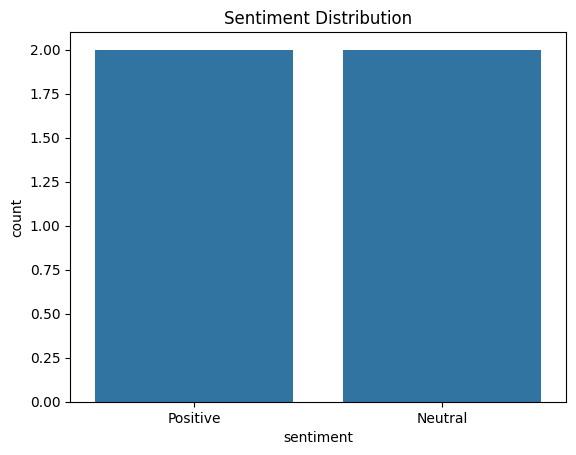

In [39]:
# Plot sentiment distribution
sns.countplot(x='sentiment', data=df_news)
plt.title('Sentiment Distribution')
plt.show()

In [40]:
# # Load a pre-trained sentiment analysis pipeline
# sentiment_pipeline = pipeline('sentiment-analysis', framework='pt')

# # Apply the sentiment pipeline
# results = sentiment_pipeline(df_news['summary'].tolist())

# # Convert the results to a DataFrame
# sentiment_df = pd.DataFrame(results)

# # Merge results with original data
# news_merge_data = pd.concat([df_news, sentiment_df], axis=1)

# # Preview the results
# news_merge_data[['summary', 'label', 'score']].head()


### Quantitative Analysis

In [41]:
# Preview the data
# print(stock_data.head())
stock_data.head()

Price,Close,High,Low,Open,Volume,SMA_50,SMA_200,EMA_50,RSI,MACD,Histogram,Signal,Position,Buy_Signal_RSI,Sell_Signal_RSI
Ticker,RPOWER.NS,RPOWER.NS,RPOWER.NS,RPOWER.NS,RPOWER.NS,,,,,,,,,,
Date,,,,,,,,,,,,,,,
2025-02-14,37.270000,39.750000,36.669998,39.590000,29114187,NaN,NaN,37.270000,NaN,NaN,NaN,0,NaN,0,0
2025-02-17,36.939999,37.889999,35.910000,37.189999,23853325,NaN,NaN,37.257059,NaN,NaN,NaN,0,0.0,0,0
2025-02-18,36.779999,37.439999,36.070000,37.150002,14308712,NaN,NaN,37.238351,NaN,NaN,NaN,0,0.0,0,0
2025-02-19,37.950001,38.400002,36.049999,36.279999,19024449,NaN,NaN,37.266259,NaN,NaN,NaN,0,0.0,0,0
2025-02-20,38.160000,38.650002,37.500000,37.900002,13736316,NaN,NaN,37.301307,NaN,NaN,NaN,0,0.0,0,0


In [42]:
# Calculate basic statistics for the closing price
mean_price = stock_data['Close'].mean()
median_price = stock_data['Close'].median()
std_dev_price = stock_data['Close'].std()
variance_price = stock_data['Close'].var()

print(f"Mean Price: {mean_price}")
print(f"Median Price: {median_price}")
print(f"Standard Deviation: {std_dev_price}")
print(f"Variance: {variance_price}")

Mean Price: Ticker
RPOWER.NS    44.375587
dtype: float64
Median Price: Ticker
RPOWER.NS    43.16
dtype: float64
Standard Deviation: Ticker
RPOWER.NS    10.81976
dtype: float64
Variance: Ticker
RPOWER.NS    117.067204
dtype: float64


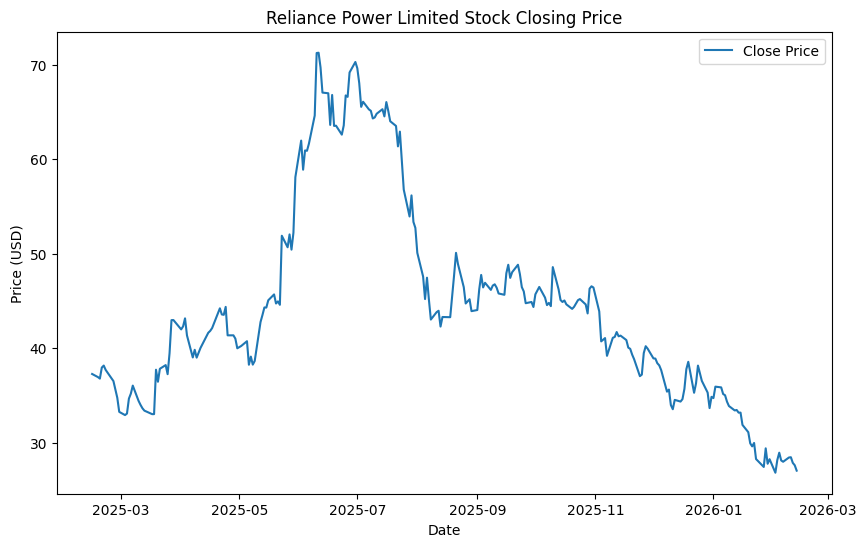

In [43]:
# Plot the closing price
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Close'], label='Close Price')
plt.title(f'{selectedCompanyName} Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


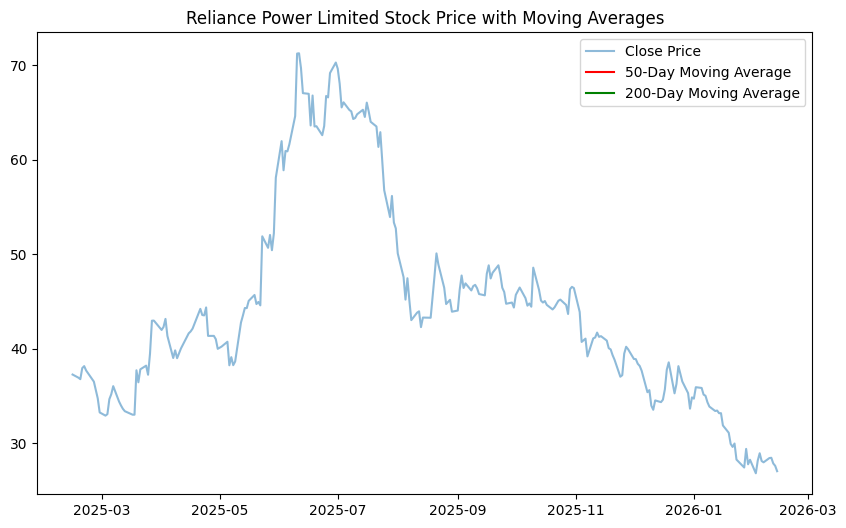

In [44]:
# Calculate 50-day and 200-day moving averages
stock_data['SMA_50'] = stock_data['Close'].rolling(window=50).mean()
stock_data['SMA_200'] = stock_data['Close'].rolling(window=200).mean()

# Plot the moving averages
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Close'], label='Close Price', alpha=0.5)
plt.plot(stock_data['SMA_50'], label='50-Day Moving Average', color='red')
plt.plot(stock_data['SMA_200'], label='200-Day Moving Average', color='green')
plt.title(f'{selectedCompanyName} Stock Price with Moving Averages')
plt.legend()
plt.show()


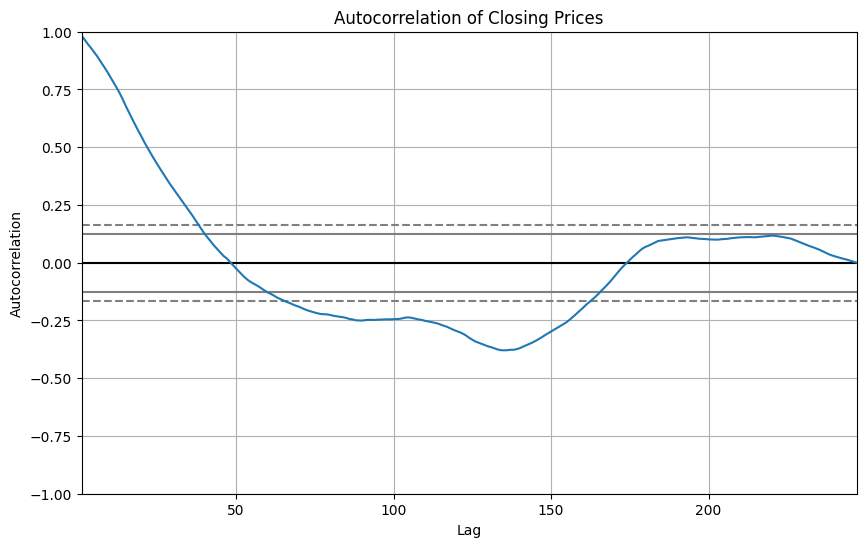

In [45]:
# Plot autocorrelation
plt.figure(figsize=(10, 6))
autocorrelation_plot(stock_data['Close'])
plt.title('Autocorrelation of Closing Prices')
plt.show()


In [46]:
# Perform ADF test
result = adfuller(stock_data['Close'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")


ADF Statistic: -0.7229389659345482
p-value: 0.8407180258714764


In [47]:
# Create a linear regression model (dependent variable: Close, independent variable: time)
stock_data['Date_Num'] = pd.to_numeric(stock_data.index)  # Convert date to numeric for regression
X = stock_data['Date_Num']
y = stock_data['Close']

# Add a constant to the independent variable for intercept
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the regression summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              RPOWER.NS   R-squared:                      -0.015
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 13 Feb 2026   Prob (F-statistic):                nan
Time:                        13:40:27   Log-Likelihood:                -939.96
No. Observations:                 247   AIC:                             1882.
Df Residuals:                     246   BIC:                             1885.
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.439e-35   2.25e-37     63.966      0.0

In [48]:
# Example: Multiple regression with stock price vs Date and Volume
X = stock_data[['Date_Num', 'Volume']]
y = stock_data['Close']

# Add constant for intercept
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              RPOWER.NS   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     11.11
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           0.000990
Time:                        13:40:28   Log-Likelihood:                -932.70
No. Observations:                 247   AIC:                             1869.
Df Residuals:                     245   BIC:                             1876.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    2

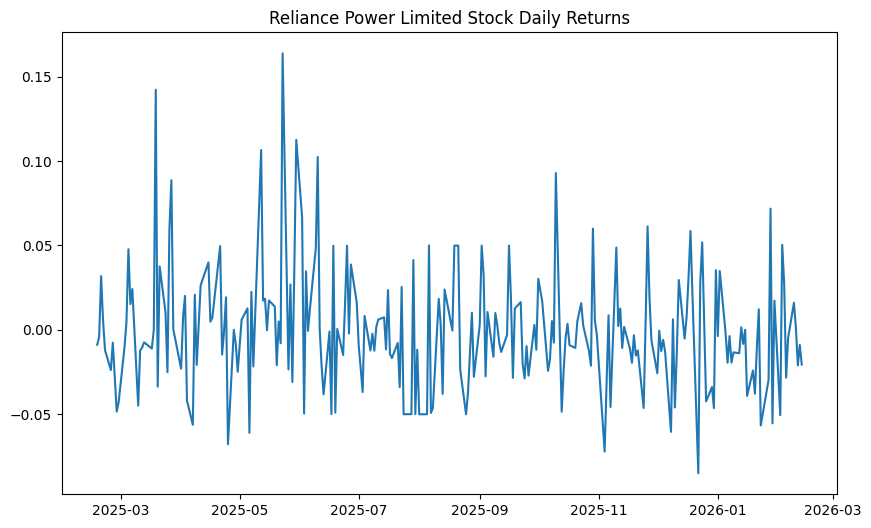

In [49]:
# Calculate daily returns
stock_data['Daily_Return'] = stock_data['Close'].pct_change()

# Plot daily returns
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Daily_Return'], label='Daily Return')
plt.title('{} Stock Daily Returns'.format(selectedCompanyName))
plt.show()


In [50]:
# Calculate annualized Sharpe Ratio
risk_free_rate = 0.01  # Example: 1% risk-free rate
sharpe_ratio = (stock_data['Daily_Return'].mean() - risk_free_rate / 252) / stock_data['Daily_Return'].std() * (252**0.5)
print(f"Sharpe Ratio: {sharpe_ratio}")


Sharpe Ratio: -0.3179453211378174


##### Simulate 10,000 scenarios for future stock price

In [51]:
num_simulations = 10000
simulation_days = 252

price = stock_data['Close'].iloc[-1].item()
daily_return = stock_data['Daily_Return'].mean()
daily_volatility = stock_data['Daily_Return'].std()

# Generate random returns
random_returns = np.random.normal(daily_return - 0.5 * daily_volatility**2, daily_volatility, (simulation_days, num_simulations))

# Create simulation matrix
simulation_matrix = np.zeros((simulation_days, num_simulations))
simulation_matrix[0] = price

# Apply Geometric Brownian Motion formula
for t in range(1, simulation_days):
    simulation_matrix[t] = simulation_matrix[t-1] * np.exp(random_returns[t])

In [52]:
# # Simulate 10,000 scenarios for future stock price
# num_simulations = 10000
# simulation_days = 252  # Number of trading days in a year
# price = stock_data['Close'].iloc[-1].item()
# daily_return = stock_data['Daily_Return'].mean()
# daily_volatility = stock_data['Daily_Return'].std()

# # Create a matrix to store the simulations
# simulation_matrix = np.zeros((simulation_days, num_simulations))

# for i in range(num_simulations):
#     simulation_matrix[0, i] = price
#     for j in range(1, simulation_days):
#         simulation_matrix[j, i] = simulation_matrix[j-1, i] * np.exp((daily_return - 0.5 * daily_volatility**2) +
#                                                                      daily_volatility * np.random.normal())

#### Plot the Simulation results

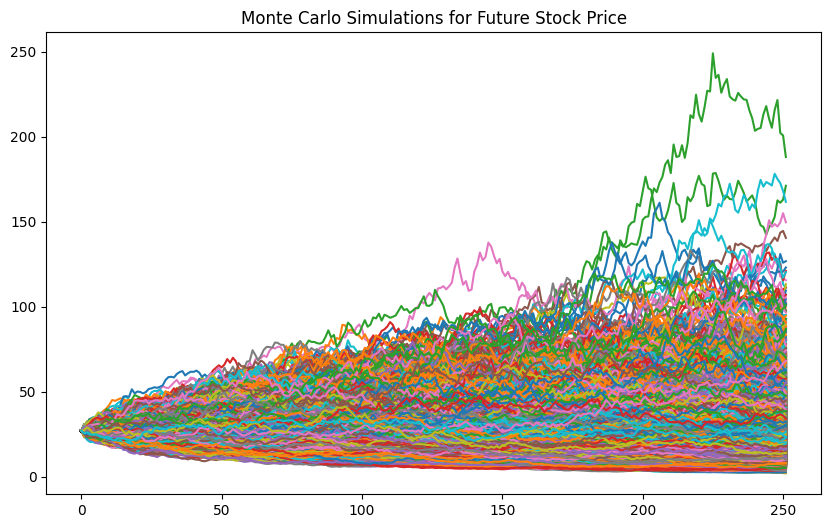

In [53]:
# Plot the simulation results
plt.figure(figsize=(10, 6))
plt.plot(simulation_matrix)
plt.title('Monte Carlo Simulations for Future Stock Price')
plt.show()

### Risk Management and Diversification

#### Historical Price of Competitors Stock Data 

In [54]:
assets = [key for key, values in competitorStocksDict.items()]

muplitple_hist_data = yf.download(assets, start=_52WeeksDate, end=currDate, auto_adjust=False)['Adj Close']

muplitple_hist_data.head()

[*********************100%***********************]  4 of 4 completed


Ticker,ADANIPOWER.NS,GVKPIL.NS,JPPOWER.NS,RTNPOWER.NS
Date,,,,
2025-02-14,97.730003,4.20,13.46,9.59
2025-02-17,98.050003,4.11,13.56,9.61
2025-02-18,96.949997,4.02,13.06,9.37
2025-02-19,96.510002,4.04,13.74,9.84
2025-02-20,96.860001,4.11,13.80,10.05


In [55]:
# # Download historical stock price data for multiple stocks
# assets = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
# data = yf.download(assets, start='2023-01-01', end='2025-01-01', auto_adjust=False)['Adj Close']

# # Preview the data
# # print(data.head())
# data.head()

In [56]:
# Calculate Daily Returns
returns = muplitple_hist_data.pct_change().dropna()

# Preview daily returns
muplitple_hist_data.head()

Ticker,ADANIPOWER.NS,GVKPIL.NS,JPPOWER.NS,RTNPOWER.NS
Date,,,,
2025-02-14,97.730003,4.20,13.46,9.59
2025-02-17,98.050003,4.11,13.56,9.61
2025-02-18,96.949997,4.02,13.06,9.37
2025-02-19,96.510002,4.04,13.74,9.84
2025-02-20,96.860001,4.11,13.80,10.05


In [57]:
# # Calculate daily returns
# returns = data.pct_change().dropna()

# # Preview daily returns
# # print(returns.head())
# returns.head()

In [58]:
# Assign equal weights for a simple diversified portfolio
weights = [0.25, 0.25, 0.25, 0.25]  # Equal weighting for 4 stocks

# Verify the sum of weights (should be 1)
print(f"sum of weights: {sum(weights)}")

# Calculate the expected portfolio return
expected_portfolio_return = (returns.mean() * weights).sum()

print(f"Expected Portfolio Return: {expected_portfolio_return:.4f}")

# Calculate covariance matrix of returns
cov_matrix = returns.cov()

# Calculate portfolio volatility (standard deviation of returns)
portfolio_volatility = np.sqrt(np.dot(weights, np.dot(cov_matrix, weights))) * np.sqrt(252)  # Annualized volatility

print(f"Portfolio Volatility (Annualized): {portfolio_volatility:.4f}")

risk_free_rate = 0.01  # Example risk-free rate (1%)

# Calculate Sharpe Ratio
sharpe_ratio = (expected_portfolio_return - risk_free_rate) / portfolio_volatility

print(f"Sharpe Ratio: {sharpe_ratio:.4f}")


sum of weights: 1.0
Expected Portfolio Return: 0.0005
Portfolio Volatility (Annualized): 0.2942
Sharpe Ratio: -0.0323


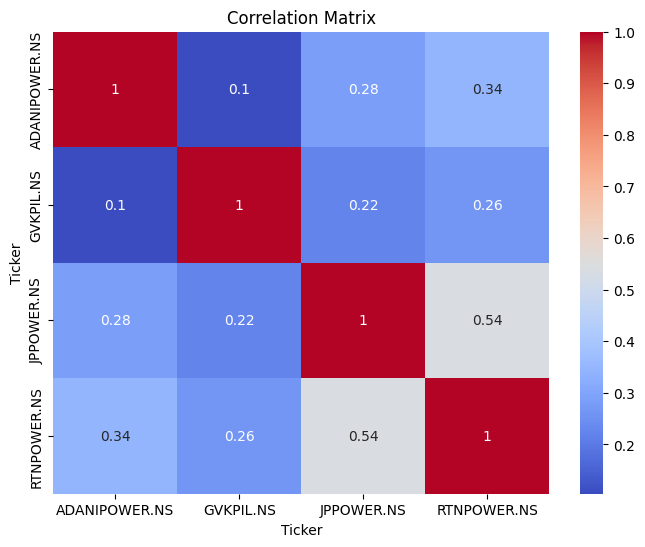

In [59]:
# Calculate correlation matrix
correlation_matrix = returns.corr()

# Visualize the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [60]:
# Number of portfolios to simulate
num_portfolios = 10000
all_weights = np.zeros((num_portfolios, len(assets)))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

# Loop through random portfolios
for i in range(num_portfolios):
    # Generate random weights for each asset
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)  # Normalize weights to sum to 1

    # Save weights
    all_weights[i, :] = weights

    # Expected return for the portfolio
    ret_arr[i] = np.sum(returns.mean() * weights) * 252

    # Expected volatility
    vol_arr[i] = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)

    # Sharpe Ratio
    sharpe_arr[i] = (ret_arr[i] - risk_free_rate) / vol_arr[i]

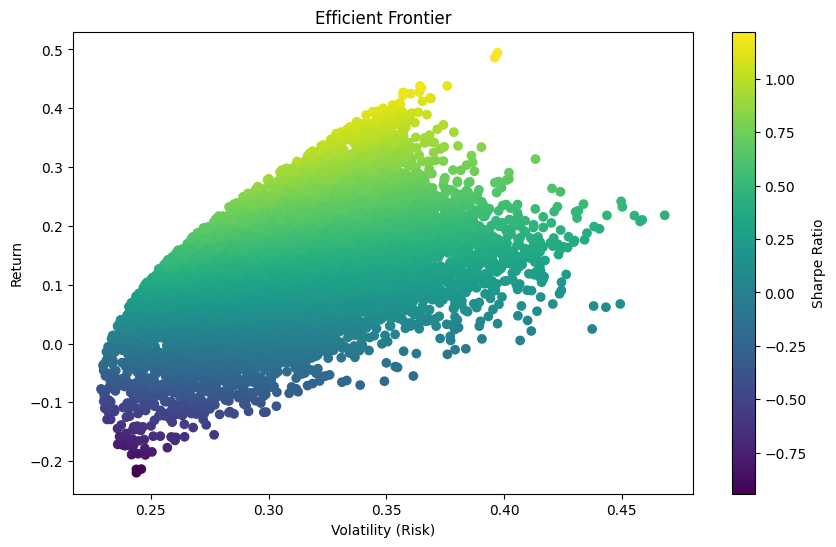

In [61]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.show()

In [62]:
# Find the index of the portfolio with the maximum Sharpe Ratio
max_sharpe_idx = sharpe_arr.argmax()

# Extract the optimal portfolio's information
optimal_weights = all_weights[max_sharpe_idx]
optimal_return = ret_arr[max_sharpe_idx]
optimal_volatility = vol_arr[max_sharpe_idx]
optimal_sharpe = sharpe_arr[max_sharpe_idx]

print(f"Optimal Weights: {optimal_weights}")
print(f"Expected Return: {optimal_return:.4f}")
print(f"Volatility: {optimal_volatility:.4f}")
print(f"Sharpe Ratio: {optimal_sharpe:.4f}")


Optimal Weights: [0.92775134 0.01641849 0.05293052 0.00289964]
Expected Return: 0.4945
Volatility: 0.3972
Sharpe Ratio: 1.2199


In [63]:
#### Calculate 5% Value at Risk (VaR)
for i in range(len(assets)):
    VaR_95 = np.percentile(returns[assets[i]], 5)
    print(f"95% Historical Value at Risk ({assets[i]}): {VaR_95:.4f}")

95% Historical Value at Risk (ADANIPOWER.NS): -0.0321
95% Historical Value at Risk (GVKPIL.NS): -0.0220
95% Historical Value at Risk (JPPOWER.NS): -0.0368
95% Historical Value at Risk (RTNPOWER.NS): -0.0377


In [64]:
# # Calculate 5% Value at Risk (VaR)
# VaR_95 = np.percentile(returns['AAPL'], 5)

# print(f"95% Historical Value at Risk (AAPL): {VaR_95:.4f}")

In [65]:
num_simulations = 10000
simulation_days = 252

for asset in assets:    
    price = muplitple_hist_data[asset].iloc[-1].item()
    daily_return = returns[asset].mean()
    daily_volatility = returns[asset].std()
    
    # Generate all random shocks at once
    random_shocks = np.random.normal(daily_return - 0.5 * daily_volatility**2, daily_volatility, (num_simulations, simulation_days))
    
    # Apply cumulative sum for GBM
    price_paths = price * np.exp(np.cumsum(random_shocks, axis=1))
    
    # Get ending prices
    sim_end_prices = price_paths[:, -1]    
    # 95% VaR
    VaR_95_mc = np.percentile(sim_end_prices, 5)    
    print(f"95% Monte Carlo Value at Risk ({asset}): {VaR_95_mc:.2f}")

95% Monte Carlo Value at Risk (ADANIPOWER.NS): 116.67
95% Monte Carlo Value at Risk (GVKPIL.NS): 1.42
95% Monte Carlo Value at Risk (JPPOWER.NS): 7.62
95% Monte Carlo Value at Risk (RTNPOWER.NS): 3.80


In [66]:
# # Generate Monte Carlo simulations for future price movements
# num_simulations = 10000
# simulation_days = 252
# for k in range(len(assets)):
#     price = muplitple_hist_data[assets[k]].iloc[-1].item()
#     daily_return = returns[assets[k]].mean()
#     daily_volatility = returns[assets[k]].std()
    
#     simulations = np.zeros((num_simulations, simulation_days))
#     for i in range(num_simulations):
#         simulations[i, 0] = price
#         for j in range(1, simulation_days):
#             simulations[i, j] = simulations[i, j-1] * np.exp((daily_return - 0.5 * daily_volatility**2) + daily_volatility * np.random.normal())
    
#     # Calculate the 5% VaR from simulated results
#     sim_end_prices = simulations[:, -1]
#     VaR_95_mc = np.percentile(sim_end_prices, 5)
    
#     print(f"95% Monte Carlo Value at Risk ({assets[k]}): {VaR_95_mc:.2f}")

In [67]:
# # Generate Monte Carlo simulations for future price movements
# num_simulations = 10000
# simulation_days = 252
# price = data['AAPL'].iloc[-1]
# daily_return = returns['AAPL'].mean()
# daily_volatility = returns['AAPL'].std()

# simulations = np.zeros((num_simulations, simulation_days))
# for i in range(num_simulations):
#     simulations[i, 0] = price
#     for j in range(1, simulation_days):
#         simulations[i, j] = simulations[i, j-1] * np.exp((daily_return - 0.5 * daily_volatility**2) + daily_volatility * np.random.normal())

# # Calculate the 5% VaR from simulated results
# sim_end_prices = simulations[:, -1]
# VaR_95_mc = np.percentile(sim_end_prices, 5)

# print(f"95% Monte Carlo Value at Risk (AAPL): {VaR_95_mc:.2f}")


In [68]:
# Simulate a market crash where all asset prices drop by 20%
market_crash = muplitple_hist_data * 0.8

# Recalculate returns, portfolio volatility, and risk metrics under stress
crash_returns = market_crash.pct_change().dropna()

# Portfolio performance under stress
crash_portfolio_return = (crash_returns.mean() * weights).sum()
crash_portfolio_volatility = np.sqrt(np.dot(weights, np.dot(crash_returns.cov(), weights))) * np.sqrt(252)

print(f"Portfolio Return during Market Crash: {crash_portfolio_return:.4f}")
print(f"Portfolio Volatility during Market Crash: {crash_portfolio_volatility:.4f}")


Portfolio Return during Market Crash: 0.0000
Portfolio Volatility during Market Crash: 0.3136


### Macroeconomic Analysis

In [ ]:
# Setup Chrome options
options = Options()
options.add_argument("--start-maximized")
options.add_argument("--headless")  # remove this if you want to see browser
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_experimental_option("excludeSwitches", ["enable-automation"])
options.add_experimental_option('useAutomationExtension', False)

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

# Open Investing calendar
driver.get("https://www.investing.com/economic-calendar/")
time.sleep(5)  # wait for page to fully load

# Wait until table loads
rows = driver.find_elements(By.CSS_SELECTOR, "#economicCalendarData tbody tr")

data = []

for row in rows:
    cols = row.find_elements(By.TAG_NAME, "td")
    if len(cols) > 0:
        data.append([col.text.strip() for col in cols])

driver.quit()

# Convert to DataFrame
columns = ["Time", "Currency", "Impact", "Event", "Actual", "Forecast", "Previous"]

df = pd.DataFrame(data, columns=columns)
df.head()

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x000001FB98E55D30>>
Traceback (most recent call last):
  File "E:\Softwares\Installation Files\Python_313\Lib\site-packages\ipykernel\ipkernel.py", line 796, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
  File "E:\Softwares\Installation Files\Python_313\Lib\threading.py", line 1480, in enumerate
    def enumerate():
KeyboardInterrupt: 


In [ ]:
# # Suppress SSL warnings
# urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# url = 'https://www.investing.com/economic-calendar/'

# # Send a request to the website
# response = requests.get(url, verify=False)
# soup = BeautifulSoup(response.text, 'html.parser')

# # Find the table containing the macroeconomic data
# table = soup.find('table', {'id': 'economicCalendarData'})

# # Parse the table
# rows = table.find_all('tr')

# data = []
# for row in rows:
#     cols = row.find_all('td')
#     data.append([col.text.strip() for col in cols])

# # Convert the list of data into a DataFrame
# df = pd.DataFrame(data) #, columns=["Date", "Cur.", "Imp.", "Event", "Actual", "Forecast", "Previous"])
# # print(df.head())
# df.head()

In [ ]:
# Example URL (you would need to adjust this to the exact data source)
url = 'https://www.rbi.org.in/Scripts/BS_viewWss.aspx' # 'https://www.rbi.org.in/Scripts/WSSView.aspx'

# Send a GET request
response = requests.get(url)
# print(response.text)
# Assuming the data is in CSV format (parse it if necessary)
# Save data as CSV or extract the relevant data fields
# For example, use Pandas to process CSV data
if response.status_code == 200:
    soup = BeautifulSoup(response.content, 'html.parser')
    # Extract Year options
    year_select = soup.find('select', {'id': 'ddlYear'})
    years = [option.text for option in year_select.find_all('option')]
    
    # Extract Month options
    month_select = soup.find('select', {'id': 'ddlMonth'})
    months = [option.text for option in month_select.find_all('option')]
    
    # Extract Archive section options
    section_select = soup.find('select', {'id': 'ddlSection'})
    sections = [option.text for option in section_select.find_all('option')]
    
    print(len(years), len(months), len(sections))
    min_length = min(len(years), len(months), len(sections))
    years = years[:min_length]
    months = months[:min_length]
    sections = sections[:min_length]
    
    # Create a DataFrame
    data = {'Year Options': years, 'Month Options': months, 'Archive Sections': sections}

    df = pd.DataFrame(data)    
    # Display the DataFrame
    print(df)
else:
    print("Failed to retrieve the page:", response.status_code)

In [ ]:
# Initialize the FRED API with your API key
fred = Fred(api_key='306e52b9780383dc719c1a16aae0a44b')

# gdp = fred.search('Consumer Price Indices (CPIs, HICPs), COICOP 1999: Consumer Price Index: Total for India')
# infl = fred.search('Inflation, consumer prices for India')
# intr_Rate = fred.search('Interest Rates: Long-Term Government Bond Yields: 10-Year: Main (Including Benchmark) for India')
# unemp_Rate = fred.search('Youth Unemployment Rate for India')
# indProd_Rate = fred.search('Production: Manufacturing: Total Manufacturing for India')

gdp_growth = fred.get_series('INDCPIALLMINMEI', )  # Change the ID for Indian GDP
inflation = fred.get_series('FPCPITOTLZGIND')  # Change the ID for Indian Inflation

interest_rate = fred.get_series('INDIRLTLT01STM')  # Change the ID for Indian Interest Rate
unemployment_rate = fred.get_series('SLUEM1524ZSIND')  # Change the ID for Unemployment Rate

industrial_production = fred.get_series('INDPRMNTO01GYSAM')  # Change the ID for Industrial Production

# Preview the GDP data
data = {'GDP Growth': gdp_growth, 'Inflation': inflation, 'Interest Rate': interest_rate, 
        'Unemployment Rate': unemployment_rate, 'Industrial Production': industrial_production}

macro_data = pd.DataFrame(data)
macro_data.dropna(inplace=True)
# print(macro_data.head())
macro_data.head()

In [ ]:
# Plot GDP, unemployment, and inflation
plt.figure(figsize=(12, 6))

plt.subplot(4, 1, 1)
plt.plot(macro_data.index, macro_data['GDP Growth'], label='GDP', color='blue')
plt.title('Indian GDP')
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(macro_data.index, macro_data['Unemployment Rate'], label='Unemployment Rate', color='green')
plt.title('Indian Unemployment Rate')
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(macro_data.index, macro_data['Inflation'], label='Inflation Rate', color='red')
plt.title('Indian Inflation Rate')
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(macro_data.index, macro_data['Industrial Production'], label='Industrial Production', color='black')
plt.title('Indian Industrial Production')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate the correlation matrix
correlation_matrix = macro_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Macroeconomic Indicators')
plt.show()

In [ ]:
# Calculate moving averages for GDP
macro_data['GDP_MA'] = macro_data['GDP Growth'].rolling(window=5).mean()
macro_data

In [ ]:
# Plot GDP and its moving average
plt.figure(figsize=(10, 5))
plt.plot(macro_data['GDP Growth'], label='GDP', color='blue')
plt.plot(macro_data['GDP_MA'], label='5-Year Moving Average', color='orange', linestyle='--')
plt.title('US GDP and 5-Year Moving Average')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Perform ADF test on GDP
adf_test = adfuller(macro_data['GDP Growth'])
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")

# If p-value < 0.05, the series is stationary


In [ ]:
# Define independent (X) and dependent (Y) variables
X = macro_data['Unemployment Rate']
Y = macro_data['GDP Growth']

# Add a constant for the intercept
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(Y, X).fit()

# Print the regression summary
model.summary()


In [ ]:
# Define multiple independent variables (Unemployment and Inflation)
X_multi = macro_data[['Unemployment Rate', 'Inflation']]
X_multi = sm.add_constant(X_multi)

# Fit the model
model_multi = sm.OLS(Y, X_multi).fit()

# Print the regression summary
model_multi.summary()


In [ ]:
# Fit ARIMA model to GDP data
model = ARIMA(macro_data['GDP Growth'], order=(5, 1, 1))  # Order (p, d, q)
arima_result = model.fit()

# Print model summary
arima_result.summary()

In [ ]:
# Forecast future GDP values
forecast = arima_result.forecast(steps=5)
forecast

In [ ]:
# Plot the forecasted values
plt.figure(figsize=(10, 5))
plt.plot(macro_data['GDP Growth'], label='Historical GDP')
plt.plot(forecast, label='Forecasted GDP', color='orange', linestyle='--')
plt.title('ARIMA Forecast for Indian GDP')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
macro_data

In [ ]:
# Download historical S&P 500 data
sp500 = yf.download(tickersListName, start=startDate, end=endDate, auto_adjust=False)['Adj Close']

# Merge with macroeconomic data
sp500_Yearly = sp500.resample('YE').mean()  # Annual resampling

# Drop missing values
# macro_data.dropna(inplace=True)
sp500_Yearly.index = sp500_Yearly.index.year
sp500_Yearly.index = pd.to_datetime(sp500_Yearly.index, format='%Y')

# Convert both to year only
macro_data['Year'] = macro_data.index.year
sp500_Yearly['Year'] = sp500_Yearly.index.year

# Merge using Year column
macro_data = pd.merge(macro_data, sp500_Yearly.reset_index()[['Year', sp500_Yearly.columns[0]]].rename(columns={sp500_Yearly.columns[0]: 'SP500'}), on='Year', how='inner')

macro_data.set_index('Year', inplace=True)
macro_data.head()

In [ ]:
# # Download historical S&P 500 data
# sp500 = yf.download(tickersListName, start=startDate, end=endDate, auto_adjust=False)['Adj Close']

# # Merge with macroeconomic data
# macro_data['SP500'] = sp500.resample('YE').mean()  # Annual resampling

# # Drop missing values
# macro_data.dropna(inplace=True)

In [ ]:
macro_data

In [ ]:
# Plot the relationship between GDP and S&P 500
plt.figure(figsize=(10, 5))
plt.plot(macro_data['GDP Growth'], label='GDP', color='blue')
plt.plot(macro_data['SP500'], label='S&P 500', color='green')
plt.title('GDP Growth vs S&P 500')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Calculate correlation between GDP and S&P 500
correlation = macro_data['GDP Growth'].corr(macro_data['SP500'])
print(f"Correlation between GDP and S&P 500: {correlation:.4f}")

### Old Techniques in ML

In [78]:
del tickHistory["Dividends"]
del tickHistory["Stock Splits"]
tickHistory["Tomorrow"] = tickHistory["Close"].shift(-1)

In [79]:
tickHistory["Target"] = (tickHistory['Tomorrow'] > tickHistory['Close']).astype(int)
# print(round(tickerName, 2))

In [80]:
tickHistory = tickHistory.loc["1990-01-01":].copy()
# print(round(tickHistory, 2))
tickHistory

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
2008-02-11 00:00:00+05:30,324.510421,324.510421,217.544439,229.606430,215028070,217.024002,0
2008-02-12 00:00:00+05:30,233.494437,241.852111,207.258075,217.024002,66575923,214.391190,0
2008-02-13 00:00:00+05:30,223.483605,225.718441,203.890522,214.391190,39014579,226.514404,1
2008-02-14 00:00:00+05:30,217.942431,229.606438,217.942431,226.514404,20221843,235.423141,1
2008-02-15 00:00:00+05:30,219.871132,238.147805,217.973052,235.423141,28134886,253.454895,1
...,...,...,...,...,...,...,...
2025-10-17 00:00:00+05:30,45.299999,45.480000,44.500000,44.639999,12405278,44.160000,0
2025-10-20 00:00:00+05:30,45.000000,45.070000,44.040001,44.160000,13555368,44.380001,1
2025-10-21 00:00:00+05:30,44.160000,44.799999,44.160000,44.380001,4186023,45.080002,1


In [81]:
model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

train = tickHistory.iloc[:-100]
test = tickHistory.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
# print(preds)

In [83]:
precision_score(test["Target"], preds, average='weighted', zero_division=0)

0.542942942942943

<Axes: xlabel='Date'>

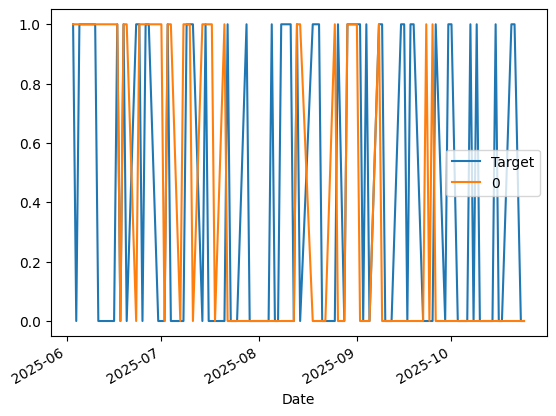

In [84]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()

In [85]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined


def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)

    return pd.concat(all_predictions)

In [86]:
predictions = backtest(tickHistory, model, predictors)
print(predictions["Predictions"].value_counts())
print()
print("Prediction Score: ", precision_score(predictions["Target"], predictions["Predictions"]))
print()
print(predictions["Target"].value_counts() / predictions.shape[0])

Predictions
0    1324
1     539
Name: count, dtype: int64

Prediction Score:  0.45083487940630795

Target
0    0.557166
1    0.442834
Name: count, dtype: float64


In [87]:
horizons = [2,5,50,60,200,250,1000]
new_predictors = []

for horizon in horizons:
    rolling_averages = tickHistory.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    tickHistory[ratio_column] = tickHistory["Close"] / rolling_averages["Close"]

    trend_column = f"Trend_{horizon}"
    tickHistory[trend_column] = tickHistory.shift(1).rolling(horizon).sum()["Target"]

    new_predictors+= [ratio_column, trend_column]

In [88]:
tickHistory = tickHistory.dropna(subset=tickHistory.columns[tickHistory.columns != "Tomorrow"])
# print(round(tickHistory, 2))
tickHistory

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Close_Ratio_50,Trend_50,Close_Ratio_60,Trend_60,Close_Ratio_200,Trend_200,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2012-03-06 00:00:00+05:30,133.428893,136.563784,122.064907,123.142525,30244117,130.245010,1,0.963034,1.0,1.003753,...,1.280615,32.0,1.333109,34.0,1.294365,101.0,1.223984,127.0,0.879419,480.0
2012-03-07 00:00:00+05:30,121.917950,131.714492,120.889318,130.245010,20431232,128.432663,0,1.028030,1.0,1.039240,...,1.338346,32.0,1.397365,35.0,1.367591,102.0,1.293605,127.0,0.930718,481.0
2012-03-09 00:00:00+05:30,132.253308,132.694149,127.061138,128.432663,13974068,132.302292,1,0.992994,1.0,1.011340,...,1.304257,32.0,1.365435,35.0,1.347147,102.0,1.275111,126.0,0.918331,481.0
2012-03-12 00:00:00+05:30,130.293998,133.918715,127.697920,132.302292,12810700,134.506516,1,1.014841,1.0,1.022874,...,1.326882,33.0,1.392675,36.0,1.385889,103.0,1.312909,126.0,0.946637,481.0
2012-03-13 00:00:00+05:30,133.232962,135.682097,132.449236,134.506516,10750063,133.477875,0,1.008261,2.0,1.036852,...,1.331949,33.0,1.401056,37.0,1.407202,103.0,1.334007,127.0,0.963104,481.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-17 00:00:00+05:30,45.299999,45.480000,44.500000,44.639999,12405278,44.160000,0,0.995429,1.0,0.988048,...,0.972685,24.0,0.945355,26.0,0.947902,95.0,0.971346,119.0,1.739584,446.0
2025-10-20 00:00:00+05:30,45.000000,45.070000,44.040001,44.160000,13555368,44.380001,1,0.994595,0.0,0.986419,...,0.963611,23.0,0.941424,25.0,0.937554,94.0,0.960699,119.0,1.718839,445.0
2025-10-21 00:00:00+05:30,44.160000,44.799999,44.160000,44.380001,4186023,45.080002,1,1.002485,1.0,0.994532,...,0.968725,24.0,0.951316,26.0,0.942260,94.0,0.965323,119.0,1.725328,446.0


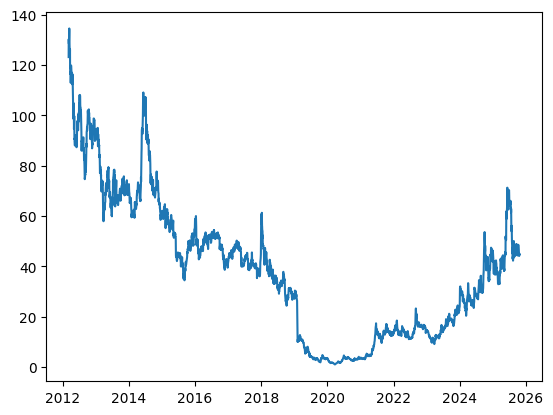

In [89]:
plt.plot(tickHistory.index, tickHistory["Close"])

In [90]:
stock_data.tail()

Price,Close,High,Low,Open,Volume,SMA_50,SMA_200,EMA_50,RSI,MACD,Histogram,Signal,Position,Buy_Signal_RSI,Sell_Signal_RSI,Date_Num,Daily_Return
Ticker,RPOWER.NS,RPOWER.NS,RPOWER.NS,RPOWER.NS,RPOWER.NS,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,
2025-10-17,44.639999,45.480000,44.500000,45.299999,12405278,NaN,NaN,47.527189,49.560765,-0.572238,0.008735,0,0.0,0,0,1760659200000000000,NaN
2025-10-20,44.160000,45.070000,44.040001,45.000000,13555368,NaN,NaN,47.395142,47.394719,-0.632641,-0.041335,0,0.0,0,0,1760918400000000000,NaN
2025-10-21,44.380001,44.799999,44.160000,44.160000,4186023,NaN,NaN,47.276901,50.072994,-0.655206,-0.051120,0,0.0,0,0,1761004800000000000,NaN
2025-10-23,45.080002,46.580002,44.410000,44.549999,32789890,NaN,NaN,47.190748,47.626344,-0.609578,-0.004393,0,0.0,0,0,1761177600000000000,NaN
2025-10-24,44.849998,45.349998,44.799999,45.299999,4977630,NaN,NaN,47.098954,43.485211,-0.585231,0.015963,0,0.0,0,0,1761264000000000000,NaN


In [91]:
tickHistory.tail()

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Close_Ratio_50,Trend_50,Close_Ratio_60,Trend_60,Close_Ratio_200,Trend_200,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-17 00:00:00+05:30,45.299999,45.480000,44.500000,44.639999,12405278,44.160000,0,0.995429,1.0,0.988048,...,0.972685,24.0,0.945355,26.0,0.947902,95.0,0.971346,119.0,1.739584,446.0
2025-10-20 00:00:00+05:30,45.000000,45.070000,44.040001,44.160000,13555368,44.380001,1,0.994595,0.0,0.986419,...,0.963611,23.0,0.941424,25.0,0.937554,94.0,0.960699,119.0,1.718839,445.0
2025-10-21 00:00:00+05:30,44.160000,44.799999,44.160000,44.380001,4186023,45.080002,1,1.002485,1.0,0.994532,...,0.968725,24.0,0.951316,26.0,0.942260,94.0,0.965323,119.0,1.725328,446.0
2025-10-23 00:00:00+05:30,44.549999,46.580002,44.410000,45.080002,32789890,44.820000,0,1.007825,2.0,1.009359,...,0.983125,25.0,0.970377,27.0,0.957245,94.0,0.980155,120.0,1.750437,446.0
2025-10-24 00:00:00+05:30,45.299999,45.349998,44.799999,44.820000,4907078,NaN,0,0.997108,1.0,1.004572,...,0.977028,24.0,0.967947,27.0,0.951823,94.0,0.973961,120.0,1.738318,445.0


In [92]:
def convert_string_date_datetime(dates):
    return datetime.strptime(dates, "%Y-%m-%d %H:%M:%S%z")

if prevDT not in weekHolidays:
    tickHistory.loc[convert_string_date_datetime(prevDT)]

In [93]:
tickHistory.loc[convert_string_date_datetime(prevDT)]

Open                4.455000e+01
High                4.658000e+01
Low                 4.441000e+01
Close               4.508000e+01
Volume              3.278989e+07
Tomorrow            4.482000e+01
Target              0.000000e+00
Close_Ratio_2       1.007825e+00
Trend_2             2.000000e+00
Close_Ratio_5       1.009359e+00
Trend_5             3.000000e+00
Close_Ratio_50      9.831247e-01
Trend_50            2.500000e+01
Close_Ratio_60      9.703771e-01
Trend_60            2.700000e+01
Close_Ratio_200     9.572447e-01
Trend_200           9.400000e+01
Close_Ratio_250     9.801552e-01
Trend_250           1.200000e+02
Close_Ratio_1000    1.750437e+00
Trend_1000          4.460000e+02
Name: 2025-10-23 00:00:00+05:30, dtype: float64

In [94]:
newData = tickHistory.tail(1)

In [95]:
def update_close_value(new_data, curr_date):
    for key, val in new_data.items():
        predValue = 0
        if key == 'Tomorrow':
            for k, v in new_data[key].items():
                if pd.Timestamp(k).date() != pd.Timestamp(curr_date).date():
                    if new_data['Target'][k] == 0:
                        predValue = new_data['Tomorrow'][k] - ((new_data['Tomorrow'][k] * new_data['Close_Ratio_2'][k]) / 100)
                    else:
                        predValue = new_data['Tomorrow'][k] + ((new_data['Tomorrow'][k] * new_data['Close_Ratio_2'][k]) / 100)
                    # newRowsData['Tomorrow'] = predValue
                    # print(new_data['Target'][k], round(predValue, 2))
                else:
                    new_data[key][k] = predValue
                    # print(new_data[key][k], predValue)
    return new_data


def update_market_value(new_data, curr_date):
    openVal, highVal, lowVal, closeVal = 0, 0, 0, 0
    res_data = {}
    for key, val in new_data.items():
        if key == 'Open':
            for k, v in new_data[key].items():
                if pd.Timestamp(k).date() == pd.Timestamp(curr_date).date():
                    openVal = new_data[key][k]
        if key == 'High':
            for k, v in new_data[key].items():
                if pd.Timestamp(k).date() == pd.Timestamp(curr_date).date():
                    highVal = new_data[key][k]
        if key == 'Low':
            for k, v in new_data[key].items():
                if pd.Timestamp(k).date() == pd.Timestamp(curr_date).date():
                    highVal = new_data[key][k]
        if key == 'Close':
            for k, v in new_data[key].items():
                if pd.Timestamp(k).date() == pd.Timestamp(curr_date).date():
                    closeVal = new_data['Tomorrow'][k]
    # print(curr_date, openVal, highVal, lowVal, closeVal)
    res_data[curr_date] = [openVal, highVal, lowVal, closeVal]
    return res_data
    # return new_data
update_market_value(newData, currDate)

{'2025-10-24': [np.float64(45.29999923706055),
  np.float64(44.79999923706055),
  0,
  np.float64(nan)]}

In [96]:
newPredData = pd.DataFrame(update_close_value(newData, currDate))
newPredData

C:\Users\Admin\AppData\Local\Temp\ipykernel_8456\2305838896.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data[key][k] = predValue


,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Close_Ratio_50,Trend_50,Close_Ratio_60,Trend_60,Close_Ratio_200,Trend_200,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-24 00:00:00+05:30,45.299999,45.349998,44.799999,44.82,4907078,0.0,0,0.997108,1.0,1.004572,...,0.977028,24.0,0.967947,27.0,0.951823,94.0,0.973961,120.0,1.738318,445.0


In [97]:
tickHistory

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Close_Ratio_50,Trend_50,Close_Ratio_60,Trend_60,Close_Ratio_200,Trend_200,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2012-03-06 00:00:00+05:30,133.428893,136.563784,122.064907,123.142525,30244117,130.245010,1,0.963034,1.0,1.003753,...,1.280615,32.0,1.333109,34.0,1.294365,101.0,1.223984,127.0,0.879419,480.0
2012-03-07 00:00:00+05:30,121.917950,131.714492,120.889318,130.245010,20431232,128.432663,0,1.028030,1.0,1.039240,...,1.338346,32.0,1.397365,35.0,1.367591,102.0,1.293605,127.0,0.930718,481.0
2012-03-09 00:00:00+05:30,132.253308,132.694149,127.061138,128.432663,13974068,132.302292,1,0.992994,1.0,1.011340,...,1.304257,32.0,1.365435,35.0,1.347147,102.0,1.275111,126.0,0.918331,481.0
2012-03-12 00:00:00+05:30,130.293998,133.918715,127.697920,132.302292,12810700,134.506516,1,1.014841,1.0,1.022874,...,1.326882,33.0,1.392675,36.0,1.385889,103.0,1.312909,126.0,0.946637,481.0
2012-03-13 00:00:00+05:30,133.232962,135.682097,132.449236,134.506516,10750063,133.477875,0,1.008261,2.0,1.036852,...,1.331949,33.0,1.401056,37.0,1.407202,103.0,1.334007,127.0,0.963104,481.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-17 00:00:00+05:30,45.299999,45.480000,44.500000,44.639999,12405278,44.160000,0,0.995429,1.0,0.988048,...,0.972685,24.0,0.945355,26.0,0.947902,95.0,0.971346,119.0,1.739584,446.0
2025-10-20 00:00:00+05:30,45.000000,45.070000,44.040001,44.160000,13555368,44.380001,1,0.994595,0.0,0.986419,...,0.963611,23.0,0.941424,25.0,0.937554,94.0,0.960699,119.0,1.718839,445.0
2025-10-21 00:00:00+05:30,44.160000,44.799999,44.160000,44.380001,4186023,45.080002,1,1.002485,1.0,0.994532,...,0.968725,24.0,0.951316,26.0,0.942260,94.0,0.965323,119.0,1.725328,446.0


In [98]:
lastDictUpdRow = tickHistory.tail(1)

In [99]:
def update_last_data(lastDtUpdRow):
    lastNewDF = pd.DataFrame(lastDtUpdRow)
    lastNewRow = lastNewDF.tail(1)
    return lastNewRow.to_dict()


def insert_last_data(lastDictUpdRow, update_date):

    openVal, highVal, lowVal, closeVal = 0, 0, 0, 0
    volVal, tomoVal, targetVal = 0, 0, 0
    cR_2, cR_5, cR_60, cR_250, cR_1000 = 0, 0, 0, 0, 0
    tR_2, tR_5, tR_60, tR_250, tR_1000 = 0, 0, 0, 0, 0


    for ks, vs in lastDictUpdRow.items():
        for k, v in lastDictUpdRow[ks].items():
            openVal = lastDictUpdRow['Open'][k]
            highVal = lastDictUpdRow['High'][k]
            lowVal = lastDictUpdRow['Low'][k]
            closeVal = lastDictUpdRow['Close'][k]

            volVal = lastDictUpdRow['Volume'][k]
            tomoVal = lastDictUpdRow['Tomorrow'][k]
            targetVal = lastDictUpdRow['Target'][k]

            if targetVal == 0:
                print(lastDictUpdRow['Target'][k]*lastDictUpdRow['Close_Ratio_2'][k])
            else:
                print(lastDictUpdRow['Target'][k]*lastDictUpdRow['Close_Ratio_2'][k])
                

            cR_2 = lastDictUpdRow['Close_Ratio_2'][k]
            tR_2 = lastDictUpdRow['Trend_2'][k]

            cR_5 = lastDictUpdRow['Close_Ratio_5'][k]
            tR_5 = lastDictUpdRow['Trend_5'][k]

            cR_60 = lastDictUpdRow['Close_Ratio_60'][k]
            tR_60 = lastDictUpdRow['Trend_60'][k]

            cR_250 = lastDictUpdRow['Close_Ratio_250'][k]
            tR_250 = lastDictUpdRow['Trend_250'][k]

            cR_1000 = lastDictUpdRow['Close_Ratio_1000'][k]
            tR_1000 = lastDictUpdRow['Trend_1000'][k]

    timeStmp = pd.Timestamp((pd.Timestamp(update_date).date()).strftime('%Y-%m-%d %H:%M:%S+0530'), tz='Asia/Kolkata')
    
    return {'Open': openVal, 'High': highVal, 'Low': lowVal, 'Close': closeVal, 'Volume': volVal, 'Tomorrow': tomoVal,
                    'Target': targetVal, 'Close_Ratio_2': cR_2, 'Trend_2': tR_2, 'Close_Ratio_5': cR_5, 'Trend_5': tR_5,
                    'Close_Ratio_60': cR_60, 'Trend_60': tR_60, 'Close_Ratio_250': cR_250, 'Trend_250': tR_250, 'Close_Ratio_1000': cR_1000,
                    'Trend_1000': tR_1000}

In [100]:
# print(newData)
lastDictUpdRow

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Close_Ratio_50,Trend_50,Close_Ratio_60,Trend_60,Close_Ratio_200,Trend_200,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-24 00:00:00+05:30,45.299999,45.349998,44.799999,44.82,4907078,0.0,0,0.997108,1.0,1.004572,...,0.977028,24.0,0.967947,27.0,0.951823,94.0,0.973961,120.0,1.738318,445.0


In [101]:
for idx in range(1):
    endDates = (pd.Timestamp(updateDT).date() + timedelta(days=1)).strftime('%Y-%m-%d %H:%M:%S+0530')
    if endDates not in tradeWeekHolidays:
        lastDictsUpdRow = insert_last_data(lastDictUpdRow, updateDT)
        updateDT = endDates
        newPredData.loc[endDates] = lastDictsUpdRow
        newPredData = pd.DataFrame(update_close_value(newPredData, endDates))
        lastDictUpdRow = update_last_data(newPredData)
    else:
       updateDT = (pd.Timestamp(endDates).date() + timedelta(days=1)).strftime('%Y-%m-%d %H:%M:%S+0530')
    # print(endDates)
newPredData

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_8456\2305838896.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data[key][k] = predValue


,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Close_Ratio_50,Trend_50,Close_Ratio_60,Trend_60,Close_Ratio_200,Trend_200,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-24 00:00:00+05:30,45.299999,45.349998,44.799999,44.82,4907078,0.0,0,0.997108,1.0,1.004572,...,0.977028,24.0,0.967947,27.0,0.951823,94.0,0.973961,120.0,1.738318,445.0
2025-10-25 00:00:00+0530,45.299999,45.349998,44.799999,44.82,4907078,0.0,0,0.997108,1.0,1.004572,...,NaN,NaN,0.967947,27.0,NaN,NaN,0.973961,120.0,1.738318,445.0


In [102]:
for idx in range(1):
    endDates = (pd.Timestamp(updateDT).date() + timedelta(days=1)).strftime('%Y-%m-%d %H:%M:%S+0530')
    lastDictsUpdRow = insert_last_data(lastDictUpdRow, updateDT)
    updateDT = endDates
    newPredData.loc[endDates] = lastDictsUpdRow
    newPredData = pd.DataFrame(update_close_value(newPredData, endDates))
    lastDictUpdRow = update_last_data(newPredData)
newPredData

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_8456\2305838896.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data[key][k] = predValue


,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Close_Ratio_50,Trend_50,Close_Ratio_60,Trend_60,Close_Ratio_200,Trend_200,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-24 00:00:00+05:30,45.299999,45.349998,44.799999,44.82,4907078,0.0,0,0.997108,1.0,1.004572,...,0.977028,24.0,0.967947,27.0,0.951823,94.0,0.973961,120.0,1.738318,445.0
2025-10-25 00:00:00+0530,45.299999,45.349998,44.799999,44.82,4907078,0.0,0,0.997108,1.0,1.004572,...,NaN,NaN,0.967947,27.0,NaN,NaN,0.973961,120.0,1.738318,445.0
2025-10-26 00:00:00+0530,45.299999,45.349998,44.799999,44.82,4907078,0.0,0,0.997108,1.0,1.004572,...,NaN,NaN,0.967947,27.0,NaN,NaN,0.973961,120.0,1.738318,445.0


## Sentiment Analysis Using Twitter

In [16]:
# Ticker example
ticker = yf.Ticker("RPOWER.NS")

# Fetch news
news_items = ticker.news

# Prepare a list of dictionaries
news_data = []
for news in news_items:
    content = news['content']
    news_data.append({
        'title': content.get('title', ''),
        'summary': content.get('summary', ''),
        'url': content['clickThroughUrl']['url'] if content.get('clickThroughUrl') else '',
        'publisher': content['provider']['displayName'] if content.get('provider') else '',
        'published_at': datetime.fromisoformat(content['pubDate'].replace('Z',''))
    })

# Convert to DataFrame
df = pd.DataFrame(news_data)

# Display
df


,title,summary,url,publisher,published_at
0,ICICI Prudential Asset becomes fourth most sub...,By Vivek Kumar M Dec 16 (Reuters) - ICICI Prud...,https://finance.yahoo.com/news/icici-prudentia...,Reuters,2025-12-16 12:18:46
1,India's e-commerce firm Meesho draws $28 billi...,"(Corrects spelling of ""institutional"" in headl...",https://finance.yahoo.com/news/indias-e-commer...,Reuters,2025-12-05 14:40:00
2,"India's Reliance Infra, Reliance Power say no ...",MUMBAI (Reuters) -A criminal investigation int...,https://finance.yahoo.com/news/indias-reliance...,Reuters,2025-08-24 09:36:04
3,Reliance Power enters long-term PPA with Green...,Reliance Power and DHI will jointly develop Bh...,https://finance.yahoo.com/news/reliance-power-...,Power Technology,2025-05-20 11:15:26


In [17]:
from textblob import TextBlob

# Function to get polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply sentiment on the 'summary' column
df['sentiment_score'] = df['summary'].apply(get_sentiment)

# Classify as Positive / Neutral / Negative
df['sentiment'] = df['sentiment_score'].apply(lambda x: 'Positive' if x>0 else ('Negative' if x<0 else 'Neutral'))

df


,title,summary,url,publisher,published_at,sentiment_score,sentiment
0,ICICI Prudential Asset becomes fourth most sub...,By Vivek Kumar M Dec 16 (Reuters) - ICICI Prud...,https://finance.yahoo.com/news/icici-prudentia...,Reuters,2025-12-16 12:18:46,0.266667,Positive
1,India's e-commerce firm Meesho draws $28 billi...,"(Corrects spelling of ""institutional"" in headl...",https://finance.yahoo.com/news/indias-e-commer...,Reuters,2025-12-05 14:40:00,0.300000,Positive
2,"India's Reliance Infra, Reliance Power say no ...",MUMBAI (Reuters) -A criminal investigation int...,https://finance.yahoo.com/news/indias-reliance...,Reuters,2025-08-24 09:36:04,-0.013333,Negative
3,Reliance Power enters long-term PPA with Green...,Reliance Power and DHI will jointly develop Bh...,https://finance.yahoo.com/news/reliance-power-...,Power Technology,2025-05-20 11:15:26,0.000000,Neutral


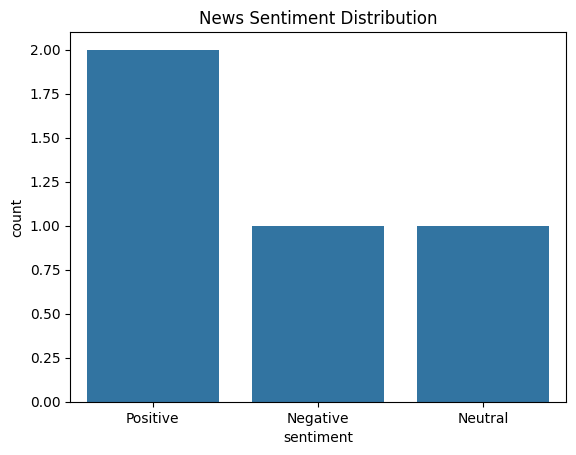

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='sentiment')
plt.title("News Sentiment Distribution")
plt.show()

### Fetch Stocks News and Sentiment

In [20]:
# Stock ticker
ticker_symbol = "RPOWER.NS"
ticker = yf.Ticker(ticker_symbol)

# Fetch news
news_items = ticker.news

# Process news
news_data = []
for news in news_items:
    content = news['content']
    news_data.append({
        'title': content.get('title', ''),
        'summary': content.get('summary', ''),
        'url': content['clickThroughUrl']['url'] if content.get('clickThroughUrl') else '',
        'publisher': content['provider']['displayName'] if content.get('provider') else '',
        'published_at': datetime.fromisoformat(content['pubDate'].replace('Z',''))
    })

df_news = pd.DataFrame(news_data)

# Sentiment Analysis
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df_news['sentiment_score'] = df_news['summary'].apply(get_sentiment)
df_news['sentiment'] = df_news['sentiment_score'].apply(lambda x: 'Positive' if x>0 else ('Negative' if x<0 else 'Neutral'))

df_news

,title,summary,url,publisher,published_at,sentiment_score,sentiment
0,ICICI Prudential Asset becomes fourth most sub...,By Vivek Kumar M Dec 16 (Reuters) - ICICI Prud...,https://finance.yahoo.com/news/icici-prudentia...,Reuters,2025-12-16 12:18:46,0.266667,Positive
1,India's e-commerce firm Meesho draws $28 billi...,"(Corrects spelling of ""institutional"" in headl...",https://finance.yahoo.com/news/indias-e-commer...,Reuters,2025-12-05 14:40:00,0.300000,Positive
2,"India's Reliance Infra, Reliance Power say no ...",MUMBAI (Reuters) -A criminal investigation int...,https://finance.yahoo.com/news/indias-reliance...,Reuters,2025-08-24 09:36:04,-0.013333,Negative
3,Reliance Power enters long-term PPA with Green...,Reliance Power and DHI will jointly develop Bh...,https://finance.yahoo.com/news/reliance-power-...,Power Technology,2025-05-20 11:15:26,0.000000,Neutral


### Fetch Historical Stock Prices

In [21]:
# Fetch stock price history
start_date = df_news['published_at'].min().date()
end_date = df_news['published_at'].max().date()

df_price = ticker.history(start=start_date, end=end_date)

# Keep only relevant columns
df_price = df_price[['Close']]
df_price.reset_index(inplace=True)
df_price.rename(columns={'Date':'published_at'}, inplace=True)

df_price

,published_at,Close
0,2025-05-20 00:00:00+05:30,44.730000
1,2025-05-21 00:00:00+05:30,44.950001
2,2025-05-22 00:00:00+05:30,44.590000
3,2025-05-23 00:00:00+05:30,51.900002
4,2025-05-26 00:00:00+05:30,50.680000
...,...,...
141,2025-12-09 00:00:00+05:30,35.619999
142,2025-12-10 00:00:00+05:30,33.980000
143,2025-12-11 00:00:00+05:30,33.540001
144,2025-12-12 00:00:00+05:30,34.529999


### Merge News and Price Data

In [22]:
# Round published_at to date only
df_news['date'] = df_news['published_at'].dt.date
df_price['date'] = df_price['published_at'].dt.date

# Merge news with stock price
df_merged = pd.merge(df_news, df_price, left_on='date', right_on='date', how='left')

df_merged[['date','title','sentiment','sentiment_score','Close']]

,date,title,sentiment,sentiment_score,Close
0,2025-12-16,ICICI Prudential Asset becomes fourth most sub...,Positive,0.266667,NaN
1,2025-12-05,India's e-commerce firm Meesho draws $28 billi...,Positive,0.300000,37.68
2,2025-08-24,"India's Reliance Infra, Reliance Power say no ...",Negative,-0.013333,NaN
3,2025-05-20,Reliance Power enters long-term PPA with Green...,Neutral,0.000000,44.73


### Correlation Analysis

In [23]:
# Simple correlation between sentiment score and stock close
correlation = df_merged['sentiment_score'].corr(df_merged['Close'])
print(f"Correlation between sentiment and stock close price: {correlation:.2f}")

Correlation between sentiment and stock close price: -1.00


### Visualization

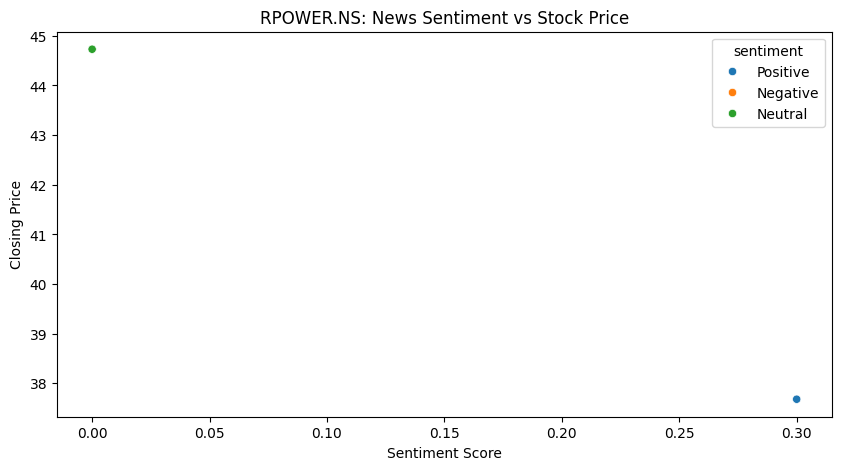

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.scatterplot(data=df_merged, x='sentiment_score', y='Close', hue='sentiment')
plt.title(f"{ticker_symbol}: News Sentiment vs Stock Price")
plt.xlabel("Sentiment Score")
plt.ylabel("Closing Price")
plt.show()


### Pre-Open Market Data

In [4]:
import requests
import pandas as pd
import time

tickersListName = "RPOWER"

HOME_URL = "https://www.nseindia.com"
PREOPEN_API = "https://www.nseindia.com/api/market-data-pre-open?key=ALL"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0 Safari/537.36",
    "Accept": "application/json,text/plain,*/*",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.nseindia.com/market-data/pre-open-market-cm-and-emerge-market",
    "Connection": "keep-alive"
}

session = requests.Session()
session.headers.update(HEADERS)

# Step 1: Get cookies
session.get(HOME_URL, timeout=10)
time.sleep(2)

# Step 2: Fetch pre-open data
response = session.get(PREOPEN_API, timeout=10)

# Safety check
if response.status_code != 200:
    raise Exception(f"HTTP Error {response.status_code}")

if "application/json" not in response.headers.get("Content-Type", ""):
    raise Exception("NSE blocked request (HTML received instead of JSON)")

data = response.json()

# Step 3: Find symbol
row = None
for item in data.get("data", []):
    meta = item.get("metadata", {})
    if meta.get("symbol") == tickersListName:
        row = {
            "Symbol": SYMBOL,
            "PrevClose": meta.get("previousClose"),
            "PreOpenPrice_IEP": meta.get("iep"),
            "Change": meta.get("change"),
            "PercentChange": meta.get("pChange"),
            "Final": meta.get("lastPrice"),
            "FinalQuantity": meta.get("finalQuantity"),
            "Value": meta.get("totalTurnover"),
            "52W_High": meta.get("yearHigh"),
            "52W_Low": meta.get("yearLow")
        }
        break

if row is None:
    print(f"⚠️ {SYMBOL} has NO pre-open activity today")
    df_symbol = pd.DataFrame()
else:
    df_symbol = pd.DataFrame([row])

df_symbol


,Symbol,PrevClose,PreOpenPrice_IEP,Change,PercentChange,Final,FinalQuantity,Value,52W_High,52W_Low
0,RPOWER,28.94,29.14,0.2,0.69,29.14,248277,7234791,76.49,25.92


In [6]:
Change_Calc = (df_symbol['PreOpenPrice_IEP'] - df_symbol['PrevClose']) / df_symbol['PrevClose'] * 100
round(Change_Calc,2)
position_52w = ((df_symbol['PreOpenPrice_IEP'] - df_symbol['52W_Low']) / (df_symbol['52W_High'] - df_symbol['52W_Low'])) * 100
round(position_52w,2)
avg_Price = df_symbol['Value'] / df_symbol['FinalQuantity']
round(avg_Price,2)

0    29.14
dtype: float64

In [15]:
stockTicker = yf.Ticker(tickersListName + ".NS")
tickHistory = stockTicker.history(period="max")

In [16]:
lastDayData = tickHistory.tail(1)
lastDayData

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-02-05 00:00:00+05:30,29.139999,29.18,28.389999,28.440001,12462350,0.0,0.0


In [17]:
last20DayData = tickHistory.tail(20)
last20DayVolume = np.average(last20DayData["Volume"])
last20DayVolume

np.float64(49439967.5)

In [13]:
openPrice = lastDayData["Open"]
closePrice = lastDayData["Close"]
highPrice = lastDayData["High"]
lowPrice = lastDayData["Low"]
volumePrice = lastDayData["Volume"]
weightedVolume = ((closePrice + highPrice + lowPrice)/3)*volumePrice
volAvgPrice = 

close_open = (closePrice > openPrice)
close_vwap = (closePrice > opePrice)

Date
2026-02-05 00:00:00+05:30    29.139999
Name: Open, dtype: float64

In [ ]:
close_open = 
intradayMomentum = close_open + close_vwap + high_open + vol_avgVol